<a href="https://colab.research.google.com/github/jomendietad/TAM-project/blob/main/TAM_pipeline_sustentacion_reducido_comentado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PROYECTO FINAL

Johan Sebastian Mendieta Dilbert

Sebastian Torres Gamboa

Christopher Andres Piedrahita Pavas

## 1. Instalación, importaciones y configuración

Esta celda prepara el entorno de trabajo. Aquí se definen:

- ruta del dataset;
- carpeta donde se guardarán resultados;
- parámetros de partición temporal;
- parámetros de clustering;
- parámetros del modelo XGBoost.


In [ ]:
# ============================================================
# 1. INSTALACIÓN, IMPORTACIONES Y CONFIGURACIÓN
# ============================================================

# sys y subprocess permiten instalar paquetes desde el propio cuaderno si falta alguna librería.
import sys
import subprocess

# XGBoost es el modelo supervisado final.
# Si no está instalado en Colab, esta parte lo instala automáticamente.
try:
    from xgboost import XGBClassifier
    print("XGBoost ya está instalado.")
except ModuleNotFoundError:
    print("Instalando XGBoost...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost"])
    from xgboost import XGBClassifier
    print("XGBoost instalado correctamente.")

# Librerías generales.
import os
import re
import json
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import display

# Herramientas de scikit-learn.
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import (
    silhouette_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 120)

# ------------------------------------------------------------
# Conexión con Google Drive
# ------------------------------------------------------------
# En Colab, montar Drive permite leer el archivo .pkl desde MyDrive.
MONTAR_DRIVE = True

if MONTAR_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as e:
        print("No se pudo montar Drive. Si no estás en Colab, ignora este mensaje.")
        print("Detalle:", e)

# ------------------------------------------------------------
# Rutas principales
# ------------------------------------------------------------
# Esta es la ruta que suministraste para la base completa.
RUTA_ARCHIVO = "/content/drive/MyDrive/Dataset_Full_Enriched_V1.pkl"

# Carpeta donde se guardarán modelos, métricas y predicciones.
CARPETA_SALIDA = "/content/drive/MyDrive/TEORIA_APRENDIZAJE_MAQUINAS/TAM_PIPELINE_SUSTENTACION_COMENTADO"
Path(CARPETA_SALIDA).mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Parámetros generales
# ------------------------------------------------------------
RANDOM_STATE = 42       # Semilla para que los resultados sean reproducibles.
UMBRAL_NULOS = 60       # Si una columna tiene más de 60% de nulos, se elimina.
ACCURACY_OBJETIVO = 0.80

# ------------------------------------------------------------
# Partición temporal
# ------------------------------------------------------------
# La base se divide respetando el orden temporal:
# train = eventos más antiguos, validación = intermedios, test = más recientes.
PORC_TRAIN = 0.70
PORC_VALID = 0.15
PORC_TEST = 0.15

# ------------------------------------------------------------
# Clustering inicial
# ------------------------------------------------------------
# El clustering inicial busca separar perfiles globales de falla.
# K=2 se deja manual porque conceptualmente queremos separar:
# 1) eventos de menor impacto y 2) eventos de mayor impacto.
K_INICIAL_MANUAL = 2

# Si lo cambias a True, el cuaderno evalúa varios valores de K con silhouette.
# Para sustentación se deja en False para reducir complejidad y tiempo de ejecución.
EVALUAR_K_INICIAL = False
K_INICIAL_MIN = 2
K_INICIAL_MAX = 12
N_MUESTRA_K_INICIAL = 50000
N_MUESTRA_SILHOUETTE = 15000

# Esta bandera controla si UITI/DURACION entran al clustering inicial.
# En este proyecto se usa True porque esas variables permiten descubrir el grupo histórico de alto impacto.
INCLUIR_IMPACTO_CLUSTER_INICIAL = True

# ------------------------------------------------------------
# Subclustering del alto impacto
# ------------------------------------------------------------
# K=3 porque el objetivo de este cuaderno es explicar tres subclases de fallas graves.
K_SUB_MANUAL = 3
EVALUAR_K_SUB = False
K_SUB_MIN = 2
K_SUB_MAX = 6
N_MUESTRA_K_SUB = 50000

# ------------------------------------------------------------
# Modelo supervisado XGBoost
# ------------------------------------------------------------
USAR_PESOS_CLASE = True  # Balancea clases cuando una clase tiene más registros que otra.

XGB_PARAMS = {
    "n_estimators": 250,
    "max_depth": 5,
    "learning_rate": 0.07,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "objective": "multi:softprob",
    "eval_metric": "mlogloss",
    "tree_method": "hist",
    "random_state": RANDOM_STATE,
    "n_jobs": -1
}

print("Configuración lista.")
print("Ruta del dataset:", RUTA_ARCHIVO)
print("Carpeta de salida:", CARPETA_SALIDA)
print("K inicial manual:", K_INICIAL_MANUAL)
print("K subclustering manual:", K_SUB_MANUAL)
print("UITI/DURACION se usan en clustering inicial:", INCLUIR_IMPACTO_CLUSTER_INICIAL)


XGBoost ya está instalado.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Configuración lista.
Ruta del dataset: /content/drive/MyDrive/Dataset_Full_Enriched_V1.pkl
Carpeta de salida: /content/drive/MyDrive/TEORIA_APRENDIZAJE_MAQUINAS/TAM_PIPELINE_SUSTENTACION_COMENTADO
K inicial manual: 2
K subclustering manual: 3
UITI/DURACION se usan en clustering inicial: True


## 2. Funciones auxiliares

Esta celda concentra funciones que se reutilizan en el cuaderno. La ventaja es que el flujo principal queda más corto y fácil de explicar.

Las funciones más importantes son:

- `limpiar_y_crear_variables`: limpia duplicados, fechas, nulos y crea variables temporales/climáticas;
- `particion_temporal`: separa train/validación/test respetando el tiempo;
- `construir_X`: crea las entradas del modelo excluyendo columnas peligrosas;
- `crear_preprocessor`: prepara números y categorías para clustering/XGBoost;
- `evaluar_kmeans`: opcionalmente evalúa varios valores de K;
- `normalizar_matriz_confusion`: ayuda a interpretar errores por clase.


In [ ]:
# ============================================================
# 2. FUNCIONES AUXILIARES
# ============================================================

# ------------------------------------------------------------
# Columnas categóricas esperadas
# ------------------------------------------------------------
# Aunque algunas parezcan numéricas, pueden tener valores tipo texto.
# Ejemplo: CALIBRE_F puede tener 2, 4, "1/0", "4/0".
# Por eso conviene tratarlas como categóricas.
POSIBLES_CATEGORICAS = [
    "TIPO",
    "NFASES",
    "NEUTRO",
    "CALIBRE_F",
    "MATERIAL_F",
    "AISLAMIENTO_F",
    "G_N",
    "CALIBRE_NEUTRO",
    "ALTURA",
    "CANTIDAD_TIERRA",
    "VEGETACION"
]

# Prefijos de variables meteorológicas horarias.
# Ejemplo: temp_0, temp_1, ..., temp_24.
PREFIJOS_CLIMA = [
    "prep",
    "pres",
    "sp",
    "rh",
    "solar_rad",
    "temp",
    "wind_gust_spd",
    "wind_spd",
    "clouds",
    "vis"
]

# Columnas que no deben entrar como variables predictoras finales.
# Motivo: son etiquetas, columnas derivadas de la etiqueta o información posterior al evento.
COLUMNAS_PELIGROSAS_BASE = [
    "CLUSTER",
    "CLUSTER_INICIAL",
    "SUBCLUSTER_ALTO",
    "PERFIL_OPERATIVO",
    "TARGET_ALTO_IMPACTO",
    "COD_CAUSA",
    "COD_CAUSA_MODEL",
    "COD_CAUSA_MODEL_ANTES_AJUSTE",
    "FECHA",
    "FECHA_OPERACION",
    "TIPO_TAXONOMIA",
    "CLASE",
    "nombre_cluster"
]

# Variables de impacto histórico.
# Se usan para construir/interpretar perfiles, pero NO entran al XGBoost final.
COLUMNAS_IMPACTO = ["UITI", "DURACION"]


def cargar_dataset(ruta_archivo):
    """
    Lee la base desde Drive o desde una ruta local.

    Soporta .pkl, .csv y .parquet.
    En tu caso principal, el archivo es .pkl.
    """
    ruta = Path(ruta_archivo)

    if not ruta.exists():
        raise FileNotFoundError(f"No existe el archivo: {ruta_archivo}")

    if ruta.suffix.lower() == ".pkl":
        df = pd.read_pickle(ruta)
    elif ruta.suffix.lower() == ".csv":
        df = pd.read_csv(ruta)
    elif ruta.suffix.lower() == ".parquet":
        df = pd.read_parquet(ruta)
    else:
        raise ValueError("Formato no soportado. Usa .pkl, .csv o .parquet")

    return df


def resumen_inicial(df):
    """
    Muestra una auditoría rápida de la base original.

    Sirve para sustentar:
    - cuántas filas y columnas tiene la base;
    - qué tipos de datos aparecen;
    - cuántos duplicados exactos existen;
    - si hay columnas con nulos.
    """
    print("Dimensión:", df.shape)
    print("\nTipos de datos:")
    display(df.dtypes.astype(str).value_counts().to_frame("cantidad"))

    print("\nDuplicados exactos:", int(df.duplicated().sum()))

    print("\nTop columnas con más nulos:")
    nulos_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
    display(nulos_pct[nulos_pct > 0].head(40).to_frame("% nulos"))

    print("\nPrimeras filas:")
    display(df.head())


def limpiar_y_crear_variables(df, umbral_nulos=60):
    """
    Limpia la base y crea variables útiles para modelado.

    Pasos internos:
    1. normaliza nombres de columnas;
    2. convierte FECHA a datetime;
    3. elimina filas sin FECHA válida;
    4. elimina duplicados exactos;
    5. reemplaza infinitos por nulos;
    6. elimina columnas con demasiados nulos;
    7. crea variables temporales desde FECHA;
    8. resume columnas meteorológicas horarias;
    9. elimina las columnas horarias originales para reducir dimensionalidad.
    """
    df = df.copy()

    # Asegura que los nombres de columnas sean texto limpio.
    df.columns = [str(c).strip() for c in df.columns]

    if "FECHA" not in df.columns:
        raise ValueError("El dataset debe tener una columna FECHA.")

    filas_iniciales = len(df)

    # Convertir FECHA permite ordenar temporalmente y crear variables de calendario.
    df["FECHA"] = pd.to_datetime(df["FECHA"], errors="coerce")
    filas_fecha_nula = int(df["FECHA"].isna().sum())
    df = df.dropna(subset=["FECHA"]).copy()

    # Eliminar duplicados evita que el modelo aprenda el mismo evento repetido.
    duplicados = int(df.duplicated().sum())
    df = df.drop_duplicates().reset_index(drop=True)

    # Infinitos no pueden ser procesados por imputadores/modelos.
    df = df.replace([np.inf, -np.inf], np.nan)

    # Se eliminan columnas muy incompletas porque pueden aportar ruido.
    nulos_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
    cols_muchos_nulos = nulos_pct[nulos_pct > umbral_nulos].index.tolist()
    df = df.drop(columns=cols_muchos_nulos, errors="ignore")

    # Variables temporales directas.
    df["ANIO"] = df["FECHA"].dt.year.astype("int32")
    df["MES"] = df["FECHA"].dt.month.astype("int32")
    df["DIA"] = df["FECHA"].dt.day.astype("int32")
    df["HORA"] = df["FECHA"].dt.hour.astype("int32")
    df["DIA_SEMANA"] = df["FECHA"].dt.dayofweek.astype("int32")
    df["FIN_SEMANA"] = df["DIA_SEMANA"].isin([5, 6]).astype("int32")

    # Variables cíclicas.
    # La hora 23 y la hora 0 están cerca; seno/coseno ayuda a representar esa circularidad.
    df["HORA_sin"] = np.sin(2 * np.pi * df["HORA"] / 24)
    df["HORA_cos"] = np.cos(2 * np.pi * df["HORA"] / 24)
    df["MES_sin"] = np.sin(2 * np.pi * df["MES"] / 12)
    df["MES_cos"] = np.cos(2 * np.pi * df["MES"] / 12)

    # Resumen de clima.
    # En vez de usar 25 columnas por variable climática, se crean promedios, máximos, mínimos y desviaciones.
    resumen_clima = []

    for prefijo in PREFIJOS_CLIMA:
        cols = [
            c for c in df.columns
            if re.fullmatch(fr"{re.escape(prefijo)}_\d+", str(c))
        ]

        if len(cols) > 0:
            df[f"{prefijo}_mean"] = df[cols].mean(axis=1)
            df[f"{prefijo}_max"] = df[cols].max(axis=1)
            df[f"{prefijo}_min"] = df[cols].min(axis=1)
            df[f"{prefijo}_std"] = df[cols].std(axis=1)

            resumen_clima.append({
                "prefijo": prefijo,
                "columnas_detectadas": len(cols),
                "resumenes": f"{prefijo}_mean, {prefijo}_max, {prefijo}_min, {prefijo}_std"
            })

    # Para precipitación también se crea suma acumulada.
    prep_cols = [c for c in df.columns if re.fullmatch(r"prep_\d+", str(c))]
    if len(prep_cols) > 0:
        df["prep_sum"] = df[prep_cols].sum(axis=1)
        resumen_clima.append({
            "prefijo": "prep",
            "columnas_detectadas": len(prep_cols),
            "resumenes": "prep_sum"
        })

    # Se eliminan las columnas horarias originales porque ya fueron resumidas.
    columnas_clima_horarias = []
    for prefijo in PREFIJOS_CLIMA:
        columnas_clima_horarias.extend([
            c for c in df.columns
            if re.fullmatch(fr"{re.escape(prefijo)}_\d+", str(c))
        ])

    columnas_clima_horarias = sorted(list(set(columnas_clima_horarias)))
    df = df.drop(columns=columnas_clima_horarias, errors="ignore")

    reporte = {
        "filas_iniciales": filas_iniciales,
        "filas_fecha_nula_eliminadas": filas_fecha_nula,
        "duplicados_eliminados": duplicados,
        "columnas_eliminadas_por_nulos": cols_muchos_nulos,
        "columnas_clima_horarias_eliminadas": columnas_clima_horarias,
        "resumen_clima": resumen_clima,
        "dimension_final": df.shape
    }

    return df, reporte


def particion_temporal(df, fecha_col="FECHA", porc_train=0.70, porc_valid=0.15):
    """
    Divide la base en train, validación y test respetando el tiempo.

    Esto simula el escenario real de empresa:
    - entrenar con eventos antiguos;
    - validar con eventos posteriores;
    - probar con eventos más recientes.
    """
    df = df.copy()
    df[fecha_col] = pd.to_datetime(df[fecha_col], errors="coerce")
    df = df.dropna(subset=[fecha_col]).sort_values(fecha_col).reset_index(drop=True)

    fechas_unicas = df[fecha_col].drop_duplicates().sort_values().reset_index(drop=True)

    if len(fechas_unicas) < 3:
        raise ValueError("Se requieren al menos 3 fechas únicas para hacer train/valid/test temporal.")

    idx_train_end = int(len(fechas_unicas) * porc_train)
    idx_val_end = int(len(fechas_unicas) * (porc_train + porc_valid))

    # Evita que algún conjunto quede vacío.
    idx_train_end = max(1, min(idx_train_end, len(fechas_unicas) - 2))
    idx_val_end = max(idx_train_end + 1, min(idx_val_end, len(fechas_unicas) - 1))

    fecha_corte_train = fechas_unicas.iloc[idx_train_end]
    fecha_corte_val = fechas_unicas.iloc[idx_val_end]

    df_train = df[df[fecha_col] < fecha_corte_train].copy()
    df_val = df[(df[fecha_col] >= fecha_corte_train) & (df[fecha_col] < fecha_corte_val)].copy()
    df_test = df[df[fecha_col] >= fecha_corte_val].copy()

    resumen = pd.DataFrame({
        "Conjunto": ["Train", "Validación", "Test"],
        "Filas": [len(df_train), len(df_val), len(df_test)],
        "Porcentaje": [
            100 * len(df_train) / len(df),
            100 * len(df_val) / len(df),
            100 * len(df_test) / len(df)
        ],
        "Fecha mínima": [df_train[fecha_col].min(), df_val[fecha_col].min(), df_test[fecha_col].min()],
        "Fecha máxima": [df_train[fecha_col].max(), df_val[fecha_col].max(), df_test[fecha_col].max()]
    })

    return df_train, df_val, df_test, fecha_corte_train, fecha_corte_val, resumen


def preparar_tipos_X(X, posibles_categoricas=POSIBLES_CATEGORICAS):
    """
    Prepara las entradas antes del OneHotEncoder.

    El error más común en este dataset es tener una columna categórica con valores mezclados:
    por ejemplo números y textos dentro de CALIBRE_F.

    Esta función convierte las columnas categóricas a texto para evitar errores como:
    "Encoders require their input argument must be uniformly strings or numbers".
    """
    X = X.copy()
    X = X.replace([np.inf, -np.inf], np.nan)

    for col in posibles_categoricas:
        if col in X.columns:
            X[col] = X[col].astype(object).replace({pd.NA: np.nan})
            X[col] = X[col].apply(lambda x: str(x) if pd.notna(x) else x)

    for col in X.select_dtypes(include=["object", "string", "category"]).columns:
        X[col] = X[col].astype(object).replace({pd.NA: np.nan})
        X[col] = X[col].apply(lambda x: str(x) if pd.notna(x) else x)

    return X


def separar_columnas_por_tipo(X):
    """
    Separa columnas numéricas y categóricas.
    Las numéricas se imputan/escalan; las categóricas se imputan/codifican con OneHotEncoder.
    """
    cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
    num_cols = [c for c in X.columns if c not in cat_cols]
    return num_cols, cat_cols


def crear_onehot():
    """
    Crea OneHotEncoder compatible con distintas versiones de scikit-learn.
    """
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)


def crear_preprocessor(num_cols, cat_cols):
    """
    Crea el preprocesador común para clustering y XGBoost.

    Numéricas:
    - imputación por mediana;
    - escalamiento estándar.

    Categóricas:
    - imputación con DESCONOCIDO;
    - OneHotEncoder.
    """
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="DESCONOCIDO")),
        ("onehot", crear_onehot())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, num_cols),
            ("cat", categorical_transformer, cat_cols)
        ],
        remainder="drop"
    )

    return preprocessor


def construir_X(df_part, columnas_excluir):
    """
    Construye la matriz de entrada X eliminando columnas prohibidas.

    Esta función es clave para evitar fuga de información.
    """
    X = df_part.drop(columns=[c for c in columnas_excluir if c in df_part.columns], errors="ignore").copy()
    X = preparar_tipos_X(X)
    return X


def evaluar_kmeans(X, k_min, k_max, n_muestra, n_silhouette, random_state=42):
    """
    Evalúa varios valores de K para KMeans usando una muestra.

    Devuelve:
    - tabla con inertia y silhouette;
    - K sugerido por mejor silhouette.

    En esta versión de sustentación se deja como función opcional.
    """
    n_total = len(X)
    if n_total < 3:
        raise ValueError("No hay suficientes filas para evaluar KMeans.")

    n_muestra_real = min(n_muestra, n_total)
    X_muestra = X.sample(n=n_muestra_real, random_state=random_state).copy()

    num_cols, cat_cols = separar_columnas_por_tipo(X_muestra)
    preprocessor_temp = crear_preprocessor(num_cols, cat_cols)
    X_trans = preprocessor_temp.fit_transform(X_muestra)

    k_max_real = min(k_max, X_trans.shape[0] - 1)
    k_min_real = max(2, min(k_min, k_max_real))

    resultados = []

    for k in range(k_min_real, k_max_real + 1):
        print(f"Probando k={k}...")

        modelo_k = MiniBatchKMeans(
            n_clusters=k,
            random_state=random_state,
            batch_size=4096,
            n_init=10,
            max_iter=150
        )

        labels_k = modelo_k.fit_predict(X_trans)

        n_sil = min(n_silhouette, X_trans.shape[0])
        rng = np.random.default_rng(random_state)
        idx_sil = rng.choice(X_trans.shape[0], size=n_sil, replace=False)

        if len(np.unique(labels_k[idx_sil])) > 1:
            sil = silhouette_score(X_trans[idx_sil], labels_k[idx_sil], metric="euclidean")
        else:
            sil = np.nan

        resultados.append({"k": k, "inertia": modelo_k.inertia_, "silhouette": sil})

    resultados = pd.DataFrame(resultados)

    if resultados["silhouette"].notna().any():
        k_sugerido = int(resultados.sort_values("silhouette", ascending=False).iloc[0]["k"])
    else:
        k_sugerido = int(resultados.sort_values("inertia", ascending=True).iloc[0]["k"])

    return resultados, k_sugerido


def normalizar_matriz_confusion(cm):
    """
    Convierte una matriz de confusión absoluta en proporciones por fila.
    Así se puede leer qué porcentaje de cada clase real fue predicho como cada clase.
    """
    return np.divide(
        cm.astype(float),
        cm.sum(axis=1, keepdims=True),
        out=np.zeros_like(cm, dtype=float),
        where=cm.sum(axis=1, keepdims=True) != 0
    )


def obtener_nombres_features(preprocessor, num_cols, cat_cols):
    """
    Recupera los nombres finales de variables después del preprocesamiento.
    Esto permite interpretar la importancia de variables de XGBoost.
    """
    nombres = list(num_cols)

    if len(cat_cols) > 0:
        ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
        nombres.extend(ohe.get_feature_names_out(cat_cols).tolist())

    return nombres


def guardar_json(obj, ruta):
    """
    Guarda configuración y resultados principales en formato JSON.
    """
    with open(ruta, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=4)


## 3. Carga y depuración de la base

Esta celda carga la base completa y realiza la limpieza inicial. Aquí ocurren los pasos más importantes de preparación:

- eliminar duplicados exactos;
- validar `FECHA`;
- eliminar columnas con muchos nulos;
- crear variables temporales;
- crear resúmenes climáticos;
- reducir la cantidad de columnas meteorológicas originales.


In [ ]:
# ============================================================
# 3. CARGA Y DEPURACIÓN
# ============================================================

# 1) Cargar el dataset desde la ruta configurada.
df_original = cargar_dataset(RUTA_ARCHIVO)
df = df_original.copy()

print("Dataset cargado correctamente.")
resumen_inicial(df)

# 2) Limpiar la base y crear variables derivadas.
df_limpio, reporte_limpieza = limpiar_y_crear_variables(df, UMBRAL_NULOS)

print("="*100)
print("REPORTE DE LIMPIEZA")
print("="*100)
print("Filas iniciales:", reporte_limpieza["filas_iniciales"])
print("Filas con FECHA nula eliminadas:", reporte_limpieza["filas_fecha_nula_eliminadas"])
print("Duplicados exactos eliminados:", reporte_limpieza["duplicados_eliminados"])
print("Columnas eliminadas por nulos:", len(reporte_limpieza["columnas_eliminadas_por_nulos"]))
print("Columnas climáticas horarias eliminadas:", len(reporte_limpieza["columnas_clima_horarias_eliminadas"]))
print("Dimensión final:", reporte_limpieza["dimension_final"])

# 3) Mostrar qué resúmenes climáticos se crearon.
if len(reporte_limpieza["resumen_clima"]) > 0:
    print("\nResúmenes climáticos creados:")
    display(pd.DataFrame(reporte_limpieza["resumen_clima"]))

# 4) Verificar nulos restantes.
print("\nTop nulos restantes:")
nulos_restantes = (df_limpio.isnull().mean() * 100).sort_values(ascending=False)
display(nulos_restantes[nulos_restantes > 0].head(30).to_frame("% nulos"))

print("\nMuestra de la base depurada:")
display(df_limpio.head())


Dataset cargado correctamente.
Dimensión: (661811, 271)

Tipos de datos:


,cantidad
float64,255
object,10
int64,4
datetime64[ns],2



Duplicados exactos: 4587

Top columnas con más nulos:


,% nulos
vis_20,100.000000
vis_21,100.000000
vis_22,100.000000
vis_23,100.000000
vis_24,100.000000
vis_4,100.000000
vis_9,100.000000
vis_5,100.000000
vis_6,100.000000
vis_7,100.000000



Primeras filas:


...

,prefijo,columnas_detectadas,resumenes
0,prep,25,"prep_mean, prep_max, prep_min, prep_std"
1,pres,25,"pres_mean, pres_max, pres_min, pres_std"
2,sp,25,"sp_mean, sp_max, sp_min, sp_std"
3,rh,25,"rh_mean, rh_max, rh_min, rh_std"
4,solar_rad,25,"solar_rad_mean, solar_rad_max, solar_rad_min, ..."
5,temp,25,"temp_mean, temp_max, temp_min, temp_std"
6,wind_gust_spd,25,"wind_gust_spd_mean, wind_gust_spd_max, wind_gu..."
7,wind_spd,25,"wind_spd_mean, wind_spd_max, wind_spd_min, win..."
8,clouds,25,"clouds_mean, clouds_max, clouds_min, clouds_std"
9,prep,25,prep_sum



Top nulos restantes:


,% nulos
CALIBRE_NEUTRO,18.283568
LONG_CRUCETA,0.445510
ALTURA,0.402602
CLASE,0.402602
TIPO_TAXONOMIA,0.011564



Muestra de la base depurada:


,TIPO,FECHA,DURACION,UITI,COD_CAUSA,NFASES,NEUTRO,LONGITUD,CALIBRE_F,MATERIAL_F,AISLAMIENTO_F,G_N,CALIBRE_NEUTRO,FECHA_OPERACION,TIPO_TAXONOMIA,CLASE,ALTURA,CANTIDAD_TIERRA,LONG_CRUCETA,VEGETACION,ENERG_CIRCULA,ANIO,MES,DIA,HORA,DIA_SEMANA,FIN_SEMANA,HORA_sin,HORA_cos,MES_sin,MES_cos,prep_mean,prep_max,prep_min,prep_std,pres_mean,pres_max,pres_min,pres_std,sp_mean,sp_max,sp_min,sp_std,rh_mean,rh_max,rh_min,rh_std,solar_rad_mean,solar_rad_max,solar_rad_min,solar_rad_std,temp_mean,temp_max,temp_min,temp_std,wind_gust_spd_mean,wind_gust_spd_max,wind_gust_spd_min,wind_gust_spd_std,wind_spd_mean,wind_spd_max,wind_spd_min,wind_spd_std,clouds_mean,clouds_max,clouds_min,clouds_std,prep_sum
0,3RG,2025-05-04 20:24:11,0.008,1.559,28,3,1,15.9,2,ACSR,DESNUDO,G,2,1980-01-01,Troncal_linea,T,12.0,0,3.0,1,3277.411667,2025,5,4,20,6,1,-0.866025,0.500000,0.500000,-0.866025,0.236,1.2,0.0,0.343851,1013.695996,1015.299988,1010.799988,1.423160,876.400361,878.719177,874.811035,1.098866,85.857001,99.067696,60.637283,12.592902,199.64,780.0,0.0,273.316648,19.722,24.400000,17.15,2.563611,14.9328,29.16,4.32,6.857441,2.900294,7.388775,0.402492,2.073743,98.44,100.0,78.0,5.091496,5.9
1,3RG,2025-05-04 20:24:43,0.017,3.137,28,3,1,15.9,2,ACSR,DESNUDO,G,2,1980-01-01,Troncal_linea,T,12.0,0,3.0,1,3277.411667,2025,5,4,20,6,1,-0.866025,0.500000,0.500000,-0.866025,0.236,1.2,0.0,0.343851,1013.695996,1015.299988,1010.799988,1.423160,876.400361,878.719177,874.811035,1.098866,85.857001,99.067696,60.637283,12.592902,199.64,780.0,0.0,273.316648,19.722,24.400000,17.15,2.563611,14.9328,29.16,4.32,6.857441,2.900294,7.388775,0.402492,2.073743,98.44,100.0,78.0,5.091496,5.9
2,3RG,2025-04-28 10:18:03,0.019,0.776,4,3,1,15.9,2,ACSR,DESNUDO,G,2,1980-01-01,Troncal_linea,T,12.0,0,3.0,1,3277.411667,2025,4,28,10,0,0,0.500000,-0.866025,0.866025,-0.500000,1.860,8.7,0.0,2.467961,1013.460000,1017.200012,1009.200012,2.248337,876.407202,879.148743,873.742188,1.565115,86.767576,99.380692,56.979858,15.586023,184.56,795.0,0.0,257.662098,20.216,25.549999,17.65,2.623600,14.0400,24.48,4.32,6.085491,2.854536,6.698806,0.569210,1.836997,98.32,100.0,81.0,4.365776,46.5
3,3RG,2025-05-04 20:39:15,0.008,1.563,23,3,1,15.9,2,ACSR,DESNUDO,G,2,1980-01-01,Troncal_linea,T,12.0,0,3.0,1,3277.411667,2025,5,4,20,6,1,-0.866025,0.500000,0.500000,-0.866025,0.236,1.2,0.0,0.343851,1013.695996,1015.299988,1010.799988,1.423160,876.400361,878.719177,874.811035,1.098866,85.857001,99.067696,60.637283,12.592902,199.64,780.0,0.0,273.316648,19.722,24.400000,17.15,2.563611,14.9328,29.16,4.32,6.857441,2.900294,7.388775,0.402492,2.073743,98.44,100.0,78.0,5.091496,5.9
4,3RG,2025-05-04 20:39:55,0.556,104.476,23,3,1,15.9,2,ACSR,DESNUDO,G,2,1980-01-01,Troncal_linea,T,12.0,0,3.0,1,3277.411667,2025,5,4,20,6,1,-0.866025,0.500000,0.500000,-0.866025,0.236,1.2,0.0,0.343851,1013.695996,1015.299988,1010.799988,1.423160,876.400361,878.719177,874.811035,1.098866,85.857001,99.067696,60.637283,12.592902,199.64,780.0,0.0,273.316648,19.722,24.400000,17.15,2.563611,14.9328,29.16,4.32,6.857441,2.900294,7.388775,0.402492,2.073743,98.44,100.0,78.0,5.091496,5.9


## 4. Partición temporal

La partición temporal es importante porque imita el uso real en empresa: el modelo aprende de eventos históricos y se evalúa en eventos posteriores.

No se mezcla aleatoriamente porque eso podría hacer que eventos muy cercanos en el tiempo queden repartidos entre train y test, inflando las métricas.


In [ ]:
# ============================================================
# 4. PARTICIÓN TEMPORAL
# ============================================================

# La función devuelve tres bases: entrenamiento, validación y test.
df_train_base, df_val_base, df_test_base, fecha_corte_train, fecha_corte_val, resumen_fechas = particion_temporal(
    df_limpio,
    fecha_col="FECHA",
    porc_train=PORC_TRAIN,
    porc_valid=PORC_VALID
)

print("Resumen de partición temporal:")
display(resumen_fechas)

# Estas comprobaciones confirman que no hay mezcla temporal entre conjuntos.
print("Train max < Val min:", df_train_base["FECHA"].max() < df_val_base["FECHA"].min())
print("Val max < Test min:", df_val_base["FECHA"].max() < df_test_base["FECHA"].min())


Resumen de partición temporal:


,Conjunto,Filas,Porcentaje,Fecha mínima,Fecha máxima
0,Train,452830,68.900405,2024-07-01 00:00:01,2025-04-25 04:21:10
1,Validación,101109,15.384253,2025-04-25 04:35:06,2025-07-07 05:51:00
2,Test,103285,15.715342,2025-07-07 05:57:23,2025-09-08 00:29:25


Train max < Val min: True
Val max < Test min: True


## 5. Clustering inicial

Aquí se entrena el primer modelo no supervisado. Su función es separar la base en grupos generales.

En esta versión se usa `K=2` para hacer una separación conceptual:

- un grupo de menor impacto;
- un grupo candidato a alto impacto.

`UITI` y `DURACION` pueden entrar aquí porque esta etapa se usa para descubrir perfiles históricos de impacto. Más adelante se excluyen del modelo XGBoost final.


In [ ]:
# ============================================================
# 5. CLUSTERING INICIAL
# ============================================================

# 1) Definir columnas que no deben usarse en el clustering inicial.
# Se excluyen identificadores de etiquetas o columnas posteriores.
columnas_excluir_cluster = COLUMNAS_PELIGROSAS_BASE.copy()

# Si se desactiva INCLUIR_IMPACTO_CLUSTER_INICIAL, también se excluyen UITI/DURACION.
# En este proyecto se deja activado porque queremos descubrir el cluster histórico de alto impacto.
if not INCLUIR_IMPACTO_CLUSTER_INICIAL:
    columnas_excluir_cluster += COLUMNAS_IMPACTO

columnas_excluir_cluster = sorted(list(set(columnas_excluir_cluster)))

# 2) Construir matrices de entrada para train, validación y test.
# Importante: el pipeline de clustering se ajusta SOLO con train.
X_cluster_train = construir_X(df_train_base, columnas_excluir_cluster)
X_cluster_val = construir_X(df_val_base, columnas_excluir_cluster)
X_cluster_test = construir_X(df_test_base, columnas_excluir_cluster)

num_cols_cluster, cat_cols_cluster = separar_columnas_por_tipo(X_cluster_train)

print("X_cluster_train:", X_cluster_train.shape)
print("Columnas numéricas clustering:", len(num_cols_cluster))
print("Columnas categóricas clustering:", len(cat_cols_cluster))
print("\nColumnas excluidas del clustering inicial:")
print([c for c in columnas_excluir_cluster if c in df_train_base.columns])

# 3) Definir K inicial.
if EVALUAR_K_INICIAL:
    resultados_k_inicial, k_sugerido_inicial = evaluar_kmeans(
        X_cluster_train,
        k_min=K_INICIAL_MIN,
        k_max=K_INICIAL_MAX,
        n_muestra=N_MUESTRA_K_INICIAL,
        n_silhouette=N_MUESTRA_SILHOUETTE,
        random_state=RANDOM_STATE
    )
    K_INICIAL_OPTIMO = int(k_sugerido_inicial)
else:
    K_INICIAL_OPTIMO = int(K_INICIAL_MANUAL)
    resultados_k_inicial = pd.DataFrame([{
        "k": K_INICIAL_OPTIMO,
        "inertia": np.nan,
        "silhouette": np.nan,
        "criterio": "K manual para separar bajo/resto vs alto impacto"
    }])

print("K inicial usado:", K_INICIAL_OPTIMO)
display(resultados_k_inicial)

# 4) Crear pipeline de clustering: primero preprocesa, luego aplica MiniBatchKMeans.
preprocessor_cluster = crear_preprocessor(num_cols_cluster, cat_cols_cluster)

modelo_cluster = MiniBatchKMeans(
    n_clusters=K_INICIAL_OPTIMO,
    random_state=RANDOM_STATE,
    batch_size=4096,
    n_init=10,
    max_iter=250
)

pipeline_cluster = Pipeline(steps=[
    ("preprocessor", preprocessor_cluster),
    ("cluster", modelo_cluster)
])

# 5) Entrenar clustering solo con train.
pipeline_cluster.fit(X_cluster_train)

# 6) Asignar cluster a train, validación y test usando el pipeline aprendido.
df_train_cluster = df_train_base.copy()
df_val_cluster = df_val_base.copy()
df_test_cluster = df_test_base.copy()

df_train_cluster["CLUSTER"] = pipeline_cluster.predict(X_cluster_train)
df_val_cluster["CLUSTER"] = pipeline_cluster.predict(X_cluster_val)
df_test_cluster["CLUSTER"] = pipeline_cluster.predict(X_cluster_test)

print("Clusters asignados correctamente.")
display(df_train_cluster["CLUSTER"].value_counts().sort_index().to_frame("cantidad_train"))


X_cluster_train: (452830, 63)
Columnas numéricas clustering: 52
Columnas categóricas clustering: 11

Columnas excluidas del clustering inicial:
['CLASE', 'COD_CAUSA', 'FECHA', 'FECHA_OPERACION', 'TIPO_TAXONOMIA']
K inicial usado: 2


,k,inertia,silhouette,criterio
0,2,NaN,NaN,K manual para separar bajo/resto vs alto impacto


Clusters asignados correctamente.


,cantidad_train
CLUSTER,
0,247012
1,205818


## 6. Identificación del cluster de alto impacto

El clustering solo produce números de grupo: 0, 1, etc. Esta celda interpreta cuál de esos grupos corresponde a mayor impacto.

La regla usada es:

> El cluster con mayor promedio de `UITI` se marca como `CLUSTER_ALTO_IMPACTO`. Si no existe `UITI`, se usa `DURACION`.


In [ ]:
# ============================================================
# 6. IDENTIFICACIÓN DEL CLUSTER DE ALTO IMPACTO
# ============================================================

# 1) Resumen de cantidad de eventos por cluster en train.
resumen_clusters_train = (
    df_train_cluster
    .groupby("CLUSTER")
    .size()
    .reset_index(name="cantidad_train")
)

resumen_clusters_train["porcentaje_train"] = 100 * resumen_clusters_train["cantidad_train"] / len(df_train_cluster)

# 2) Verificar qué variables de impacto existen.
variables_impacto_disponibles = [c for c in COLUMNAS_IMPACTO if c in df_train_cluster.columns]

if len(variables_impacto_disponibles) == 0:
    raise ValueError("No se encontró UITI ni DURACION. Se necesita al menos una variable de impacto para identificar alto impacto.")

# Se prioriza UITI porque suele medir afectación operativa.
VARIABLE_IMPACTO_PRINCIPAL = "UITI" if "UITI" in variables_impacto_disponibles else variables_impacto_disponibles[0]

# 3) Calcular estadísticas de impacto por cluster.
impacto_cluster_train = (
    df_train_cluster
    .groupby("CLUSTER")[variables_impacto_disponibles]
    .agg(["count", "mean", "median", "max", "std"])
)

print("Impacto histórico por cluster en train:")
display(impacto_cluster_train)

# 4) Seleccionar como alto impacto el cluster con mayor promedio en la variable principal.
impacto_promedio = (
    df_train_cluster
    .groupby("CLUSTER")[VARIABLE_IMPACTO_PRINCIPAL]
    .mean()
    .sort_values(ascending=False)
)

CLUSTER_ALTO_IMPACTO = int(impacto_promedio.index[0])

print("Variable usada para definir alto impacto:", VARIABLE_IMPACTO_PRINCIPAL)
print("Cluster de alto impacto seleccionado:", CLUSTER_ALTO_IMPACTO)

# 5) Crear una tabla de interpretación básica de clusters.
tabla_clusters = resumen_clusters_train.copy()

for col in variables_impacto_disponibles:
    tabla_clusters = tabla_clusters.merge(
        df_train_cluster.groupby("CLUSTER")[col].mean().reset_index(name=f"{col}_promedio_train"),
        on="CLUSTER",
        how="left"
    )

# Causa dominante por cluster, si existe COD_CAUSA.
if "COD_CAUSA" in df_train_cluster.columns:
    causa_cluster = (
        df_train_cluster
        .groupby(["CLUSTER", "COD_CAUSA"])
        .size()
        .reset_index(name="cantidad")
    )
    causa_cluster["porcentaje_en_cluster"] = (
        causa_cluster["cantidad"] /
        causa_cluster.groupby("CLUSTER")["cantidad"].transform("sum") * 100
    )

    causa_top1 = (
        causa_cluster
        .sort_values(["CLUSTER", "cantidad"], ascending=[True, False])
        .groupby("CLUSTER")
        .head(1)
        [["CLUSTER", "COD_CAUSA", "porcentaje_en_cluster"]]
        .rename(columns={
            "COD_CAUSA": "causa_dominante_train",
            "porcentaje_en_cluster": "porcentaje_causa_dominante_train"
        })
    )

    tabla_clusters = tabla_clusters.merge(causa_top1, on="CLUSTER", how="left")

# Tipo dominante por cluster, si existe TIPO.
if "TIPO" in df_train_cluster.columns:
    tipo_cluster = (
        df_train_cluster
        .groupby(["CLUSTER", "TIPO"])
        .size()
        .reset_index(name="cantidad")
    )
    tipo_cluster["porcentaje_en_cluster"] = (
        tipo_cluster["cantidad"] /
        tipo_cluster.groupby("CLUSTER")["cantidad"].transform("sum") * 100
    )

    tipo_top1 = (
        tipo_cluster
        .sort_values(["CLUSTER", "cantidad"], ascending=[True, False])
        .groupby("CLUSTER")
        .head(1)
        [["CLUSTER", "TIPO", "porcentaje_en_cluster"]]
        .rename(columns={
            "TIPO": "tipo_dominante_train",
            "porcentaje_en_cluster": "porcentaje_tipo_dominante_train"
        })
    )

    tabla_clusters = tabla_clusters.merge(tipo_top1, on="CLUSTER", how="left")

tabla_clusters["perfil_impacto"] = np.where(
    tabla_clusters["CLUSTER"] == CLUSTER_ALTO_IMPACTO,
    "ALTO_IMPACTO",
    "BAJO_O_MEDIO_IMPACTO"
)

print("Resumen interpretativo de clusters:")
display(tabla_clusters)


Impacto histórico por cluster en train:


UITI                                             DURACION  \
          count        mean  median        max          std    count   
CLUSTER                                                                
0        247012  432.404470  35.374  35841.591  1472.159581   247012   
1        205818  295.958908  22.809  28927.084  1086.311129   205818   

                                            
             mean median     max       std  
CLUSTER                                     
0        2.120262  0.032  607.20  7.404722  
1        2.018152  0.030  239.96  6.144826

Variable usada para definir alto impacto: UITI
Cluster de alto impacto seleccionado: 0
Resumen interpretativo de clusters:


,CLUSTER,cantidad_train,porcentaje_train,UITI_promedio_train,DURACION_promedio_train,causa_dominante_train,porcentaje_causa_dominante_train,tipo_dominante_train,porcentaje_tipo_dominante_train,perfil_impacto
0,0,247012,54.548506,432.404470,2.120262,28,32.479799,3IG,30.657620,ALTO_IMPACTO
1,1,205818,45.451494,295.958908,2.018152,28,32.214384,3IG,26.744988,BAJO_O_MEDIO_IMPACTO


## 7. Subclustering de eventos de alto impacto

Después de identificar el cluster grave, se toma solo ese grupo y se divide en 3 subgrupos.

Esto permite que el proyecto no se quede en “grave/no grave”, sino que diferencie tres tipos de fallas graves.

Punto clave: para el subclustering se excluyen `UITI` y `DURACION`, porque ya sabemos que estamos dentro del grupo grave y queremos diferenciar perfiles por condiciones técnicas, temporales y climáticas.


In [ ]:
# ============================================================
# 7. SUBCLUSTERING DEL ALTO IMPACTO
# ============================================================

# 1) Filtrar eventos que pertenecen al cluster de alto impacto.
df_train_alto = df_train_cluster[df_train_cluster["CLUSTER"] == CLUSTER_ALTO_IMPACTO].copy()
df_val_alto = df_val_cluster[df_val_cluster["CLUSTER"] == CLUSTER_ALTO_IMPACTO].copy()
df_test_alto = df_test_cluster[df_test_cluster["CLUSTER"] == CLUSTER_ALTO_IMPACTO].copy()

print("Eventos alto impacto train:", df_train_alto.shape)
print("Eventos alto impacto validación:", df_val_alto.shape)
print("Eventos alto impacto test:", df_test_alto.shape)

if len(df_train_alto) < 3:
    raise ValueError("Hay muy pocos eventos de alto impacto en train para subclustering.")

# 2) Para subclustering se excluyen columnas peligrosas y también UITI/DURACION.
columnas_excluir_subcluster = sorted(list(set(
    COLUMNAS_PELIGROSAS_BASE + COLUMNAS_IMPACTO
)))

X_sub_train = construir_X(df_train_alto, columnas_excluir_subcluster)
num_cols_sub, cat_cols_sub = separar_columnas_por_tipo(X_sub_train)

print("X_sub_train:", X_sub_train.shape)
print("Numéricas subclustering:", len(num_cols_sub))
print("Categóricas subclustering:", len(cat_cols_sub))
print("\nColumnas excluidas del subclustering:")
print([c for c in columnas_excluir_subcluster if c in df_train_alto.columns])

# 3) Definir K del subclustering.
if EVALUAR_K_SUB:
    resultados_k_sub, k_sugerido_sub = evaluar_kmeans(
        X_sub_train,
        k_min=K_SUB_MIN,
        k_max=K_SUB_MAX,
        n_muestra=N_MUESTRA_K_SUB,
        n_silhouette=N_MUESTRA_SILHOUETTE,
        random_state=RANDOM_STATE
    )
    K_SUB_OPTIMO = int(k_sugerido_sub)
    criterio_k_sub = "automático por mejor silhouette"
else:
    K_SUB_OPTIMO = int(K_SUB_MANUAL)
    criterio_k_sub = "manual para conservar tres subclases de fallas graves"
    resultados_k_sub = pd.DataFrame([{
        "k": K_SUB_OPTIMO,
        "inertia": np.nan,
        "silhouette": np.nan,
        "criterio": criterio_k_sub
    }])

print("K subcluster usado:", K_SUB_OPTIMO)
print("Criterio usado:", criterio_k_sub)
display(resultados_k_sub)

# 4) Entrenar el subclustering solo con eventos graves de train.
preprocessor_sub = crear_preprocessor(num_cols_sub, cat_cols_sub)

modelo_subcluster = MiniBatchKMeans(
    n_clusters=K_SUB_OPTIMO,
    random_state=RANDOM_STATE,
    batch_size=4096,
    n_init=10,
    max_iter=250
)

pipeline_subcluster = Pipeline(steps=[
    ("preprocessor", preprocessor_sub),
    ("subcluster", modelo_subcluster)
])

pipeline_subcluster.fit(X_sub_train)

print("Subclustering entrenado correctamente con K_SUB_OPTIMO =", K_SUB_OPTIMO)


Eventos alto impacto train: (247012, 69)
Eventos alto impacto validación: (64800, 69)
Eventos alto impacto test: (30594, 69)
X_sub_train: (247012, 61)
Numéricas subclustering: 50
Categóricas subclustering: 11

Columnas excluidas del subclustering:
['CLASE', 'CLUSTER', 'COD_CAUSA', 'DURACION', 'FECHA', 'FECHA_OPERACION', 'TIPO_TAXONOMIA', 'UITI']
K subcluster usado: 3
Criterio usado: manual para conservar tres subclases de fallas graves


,k,inertia,silhouette,criterio
0,3,NaN,NaN,manual para conservar tres subclases de fallas...


Subclustering entrenado correctamente con K_SUB_OPTIMO = 3


## 8. Creación de `PERFIL_OPERATIVO`

Esta celda crea la variable objetivo final que aprenderá XGBoost.

Regla:

- si el evento no está en el cluster de alto impacto → `BAJO_IMPACTO`;
- si el evento sí está en el cluster de alto impacto → se clasifica con el subclustering como `ALTO_IMPACTO_SUB0`, `ALTO_IMPACTO_SUB1` o `ALTO_IMPACTO_SUB2`.


In [ ]:
# ============================================================
# 8. CREACIÓN DE PERFIL_OPERATIVO
# ============================================================

def asignar_perfil_operativo(df_part):
    """
    Asigna la etiqueta final PERFIL_OPERATIVO a una partición.

    Esta función no entrena nada nuevo:
    - usa el CLUSTER ya asignado;
    - usa pipeline_subcluster para clasificar solo los eventos graves.
    """
    df_part = df_part.copy()

    # TARGET_ALTO_IMPACTO vale 1 si el evento pertenece al cluster crítico.
    df_part["TARGET_ALTO_IMPACTO"] = (df_part["CLUSTER"] == CLUSTER_ALTO_IMPACTO).astype(int)

    # Por defecto, todo evento se considera bajo impacto.
    df_part["SUBCLUSTER_ALTO"] = pd.NA
    df_part["PERFIL_OPERATIVO"] = "BAJO_IMPACTO"

    # Solo los eventos del cluster crítico reciben subperfil grave.
    mask_alto = df_part["CLUSTER"] == CLUSTER_ALTO_IMPACTO

    if mask_alto.sum() > 0:
        X_alto = construir_X(df_part.loc[mask_alto], columnas_excluir_subcluster)
        subclusters = pipeline_subcluster.predict(X_alto)

        df_part.loc[mask_alto, "SUBCLUSTER_ALTO"] = subclusters
        df_part.loc[mask_alto, "PERFIL_OPERATIVO"] = [
            f"ALTO_IMPACTO_SUB{int(s)}" for s in subclusters
        ]

    return df_part

# Aplicar la función a cada partición.
df_train_perfil = asignar_perfil_operativo(df_train_cluster)
df_val_perfil = asignar_perfil_operativo(df_val_cluster)
df_test_perfil = asignar_perfil_operativo(df_test_cluster)

# Unir todo para análisis descriptivo posterior.
df_perfil_completo = pd.concat(
    [df_train_perfil.assign(CONJUNTO="train"),
     df_val_perfil.assign(CONJUNTO="validacion"),
     df_test_perfil.assign(CONJUNTO="test")],
    axis=0
).sort_values("FECHA").reset_index(drop=True)

print("Distribución PERFIL_OPERATIVO en train:")
display(df_train_perfil["PERFIL_OPERATIVO"].value_counts().to_frame("cantidad"))

print("\nDistribución PERFIL_OPERATIVO en validación:")
display(df_val_perfil["PERFIL_OPERATIVO"].value_counts().to_frame("cantidad"))

print("\nDistribución PERFIL_OPERATIVO en test:")
display(df_test_perfil["PERFIL_OPERATIVO"].value_counts().to_frame("cantidad"))


Distribución PERFIL_OPERATIVO en train:


,cantidad
PERFIL_OPERATIVO,
BAJO_IMPACTO,205818
ALTO_IMPACTO_SUB1,95679
ALTO_IMPACTO_SUB0,86269
ALTO_IMPACTO_SUB2,65064



Distribución PERFIL_OPERATIVO en validación:


,cantidad
PERFIL_OPERATIVO,
BAJO_IMPACTO,36309
ALTO_IMPACTO_SUB1,24662
ALTO_IMPACTO_SUB0,20321
ALTO_IMPACTO_SUB2,19817



Distribución PERFIL_OPERATIVO en test:


,cantidad
PERFIL_OPERATIVO,
BAJO_IMPACTO,72691
ALTO_IMPACTO_SUB1,17673
ALTO_IMPACTO_SUB0,8107
ALTO_IMPACTO_SUB2,4814


## 9. Interpretación automática de perfiles

Esta celda ayuda en la sustentación. No entrena el modelo, pero permite explicar qué caracteriza a cada perfil.

Muestra:

- cantidad de eventos por perfil;
- promedio/mediana de `UITI` y `DURACION`;
- causa dominante si existe `COD_CAUSA`;
- tipo dominante si existe `TIPO`.


In [ ]:
# ============================================================
# 9. INTERPRETACIÓN AUTOMÁTICA DE PERFILES
# ============================================================

# 1) Resumen de impacto por perfil.
cols_impacto_presentes = [c for c in COLUMNAS_IMPACTO if c in df_perfil_completo.columns]

if len(cols_impacto_presentes) > 0:
    resumen_perfiles = (
        df_perfil_completo
        .groupby("PERFIL_OPERATIVO")[cols_impacto_presentes]
        .agg(["count", "mean", "median", "max", "std"])
    )
    print("Resumen de impacto por perfil operativo:")
    display(resumen_perfiles)
else:
    print("No hay columnas UITI/DURACION para resumir impacto.")

# 2) Causa dominante por perfil.
if "COD_CAUSA" in df_perfil_completo.columns:
    causa_perfil = (
        df_perfil_completo
        .groupby(["PERFIL_OPERATIVO", "COD_CAUSA"])
        .size()
        .reset_index(name="cantidad")
    )
    causa_perfil["porcentaje_en_perfil"] = (
        causa_perfil["cantidad"] /
        causa_perfil.groupby("PERFIL_OPERATIVO")["cantidad"].transform("sum") * 100
    )

    causa_top = (
        causa_perfil
        .sort_values(["PERFIL_OPERATIVO", "cantidad"], ascending=[True, False])
        .groupby("PERFIL_OPERATIVO")
        .head(5)
    )

    print("Top 5 causas por perfil:")
    display(causa_top)

# 3) Tipo dominante por perfil.
if "TIPO" in df_perfil_completo.columns:
    tipo_perfil = (
        df_perfil_completo
        .groupby(["PERFIL_OPERATIVO", "TIPO"])
        .size()
        .reset_index(name="cantidad")
    )
    tipo_perfil["porcentaje_en_perfil"] = (
        tipo_perfil["cantidad"] /
        tipo_perfil.groupby("PERFIL_OPERATIVO")["cantidad"].transform("sum") * 100
    )

    tipo_top = (
        tipo_perfil
        .sort_values(["PERFIL_OPERATIVO", "cantidad"], ascending=[True, False])
        .groupby("PERFIL_OPERATIVO")
        .head(5)
    )

    print("Top 5 tipos por perfil:")
    display(tipo_top)


Resumen de impacto por perfil operativo:


UITI                                              \
                    count        mean  median        max          std   
PERFIL_OPERATIVO                                                        
ALTO_IMPACTO_SUB0  114697  460.890758  42.575  35841.591  1655.201766   
ALTO_IMPACTO_SUB1  138014  448.052536  50.849  33141.353  1359.315270   
ALTO_IMPACTO_SUB2   89695  345.362601  17.319  35887.985  1339.499695   
BAJO_IMPACTO       314818  293.789872  22.901  28927.084  1091.783544   

                  DURACION                                     
                     count      mean median     max       std  
PERFIL_OPERATIVO                                               
ALTO_IMPACTO_SUB0   114697  1.920950  0.033  607.20  5.963060  
ALTO_IMPACTO_SUB1   138014  2.006892  0.038  102.90  5.603934  
ALTO_IMPACTO_SUB2    89695  2.457374  0.024  607.20  9.641707  
BAJO_IMPACTO        314818  1.993059  0.031  239.96  5.740517

Top 5 causas por perfil:


,PERFIL_OPERATIVO,COD_CAUSA,cantidad,porcentaje_en_perfil
20,ALTO_IMPACTO_SUB0,28,38494,33.561471
17,ALTO_IMPACTO_SUB0,23,30013,26.167206
21,ALTO_IMPACTO_SUB0,29,13750,11.988108
14,ALTO_IMPACTO_SUB0,20,8893,7.753472
1,ALTO_IMPACTO_SUB0,4,8451,7.368109
51,ALTO_IMPACTO_SUB1,28,39219,28.416682
47,ALTO_IMPACTO_SUB1,23,26976,19.545843
52,ALTO_IMPACTO_SUB1,29,18923,13.710928
44,ALTO_IMPACTO_SUB1,20,14803,10.725723
31,ALTO_IMPACTO_SUB1,4,14457,10.475024


Top 5 tipos por perfil:


,PERFIL_OPERATIVO,TIPO,cantidad,porcentaje_en_perfil
10,ALTO_IMPACTO_SUB0,3IG,35257,30.739252
13,ALTO_IMPACTO_SUB0,3RL,28221,24.604828
12,ALTO_IMPACTO_SUB0,3RG,25011,21.806150
7,ALTO_IMPACTO_SUB0,3CC,10063,8.773551
8,ALTO_IMPACTO_SUB0,3CFR,5599,4.881557
24,ALTO_IMPACTO_SUB1,3IG,57567,41.710986
27,ALTO_IMPACTO_SUB1,3RL,39664,28.739113
26,ALTO_IMPACTO_SUB1,3RG,13527,9.801180
17,ALTO_IMPACTO_SUB1,2CC,7665,5.553784
21,ALTO_IMPACTO_SUB1,3CC,6743,4.885736


## 10. Preparación del dataset supervisado

Aquí empieza la parte supervisada.

Se crea:

- `X`: variables de entrada para XGBoost;
- `y`: etiqueta que queremos predecir, es decir `PERFIL_OPERATIVO`.

En esta etapa se excluyen `UITI`, `DURACION`, `CLUSTER`, `SUBCLUSTER_ALTO` y otras columnas peligrosas para evitar fuga de información.


In [ ]:
# ============================================================
# 10. DATASET SUPERVISADO
# ============================================================

TARGET = "PERFIL_OPERATIVO"

# Estas columnas no entran al XGBoost final.
# Esta es la parte que debes enfatizar si te preguntan por fuga de información.
columnas_excluir_supervisado = sorted(list(set(
    COLUMNAS_PELIGROSAS_BASE + COLUMNAS_IMPACTO
)))


def separar_X_y_supervisado(df_part):
    """
    Separa una partición en entradas X y salida y.
    """
    y = df_part[TARGET].astype(str).copy()
    X = construir_X(df_part, columnas_excluir_supervisado)
    return X, y

# Separar cada conjunto.
X_train_sup, y_train_sup = separar_X_y_supervisado(df_train_perfil)
X_val_sup, y_val_sup = separar_X_y_supervisado(df_val_perfil)
X_test_sup, y_test_sup = separar_X_y_supervisado(df_test_perfil)

print("Columnas excluidas del modelo supervisado:")
print([c for c in columnas_excluir_supervisado if c in df_train_perfil.columns])

print("\nDimensiones:")
print("X_train_sup:", X_train_sup.shape, "| y_train_sup:", y_train_sup.shape)
print("X_val_sup:  ", X_val_sup.shape, "| y_val_sup:  ", y_val_sup.shape)
print("X_test_sup: ", X_test_sup.shape, "| y_test_sup: ", y_test_sup.shape)

print("\nClases en train:")
display(y_train_sup.value_counts().to_frame("cantidad"))

print("\nClases en validación:")
display(y_val_sup.value_counts().to_frame("cantidad"))

print("\nClases en test:")
display(y_test_sup.value_counts().to_frame("cantidad"))

# Validación importante: XGBoost no puede predecir clases que nunca vio en entrenamiento.
clases_train = set(y_train_sup.unique())
clases_val_test = set(y_val_sup.unique()).union(set(y_test_sup.unique()))
clases_no_vistas = sorted(list(clases_val_test - clases_train))

if len(clases_no_vistas) > 0:
    raise ValueError(
        "Hay clases en validación/test que no existen en train: "
        + str(clases_no_vistas)
        + ". Revisa la partición temporal o la construcción del perfil."
    )


Columnas excluidas del modelo supervisado:
['CLASE', 'CLUSTER', 'COD_CAUSA', 'DURACION', 'FECHA', 'FECHA_OPERACION', 'PERFIL_OPERATIVO', 'SUBCLUSTER_ALTO', 'TARGET_ALTO_IMPACTO', 'TIPO_TAXONOMIA', 'UITI']

Dimensiones:
X_train_sup: (452830, 61) | y_train_sup: (452830,)
X_val_sup:   (101109, 61) | y_val_sup:   (101109,)
X_test_sup:  (103285, 61) | y_test_sup:  (103285,)

Clases en train:


,cantidad
PERFIL_OPERATIVO,
BAJO_IMPACTO,205818
ALTO_IMPACTO_SUB1,95679
ALTO_IMPACTO_SUB0,86269
ALTO_IMPACTO_SUB2,65064



Clases en validación:


,cantidad
PERFIL_OPERATIVO,
BAJO_IMPACTO,36309
ALTO_IMPACTO_SUB1,24662
ALTO_IMPACTO_SUB0,20321
ALTO_IMPACTO_SUB2,19817



Clases en test:


,cantidad
PERFIL_OPERATIVO,
BAJO_IMPACTO,72691
ALTO_IMPACTO_SUB1,17673
ALTO_IMPACTO_SUB0,8107
ALTO_IMPACTO_SUB2,4814


## 11. Codificación del target y preprocesamiento supervisado

XGBoost necesita que la salida sea numérica. Por eso se usa `LabelEncoder`:

- `BAJO_IMPACTO` → número;
- `ALTO_IMPACTO_SUB0` → número;
- etc.

Además, se crea un preprocesador para manejar columnas numéricas y categóricas.


In [ ]:
# ============================================================
# 11. CODIFICACIÓN Y PREPROCESAMIENTO SUPERVISADO
# ============================================================

# LabelEncoder convierte nombres de clases en números.
label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train_sup)
y_val_enc = label_encoder.transform(y_val_sup)
y_test_enc = label_encoder.transform(y_test_sup)

clases_perfil = label_encoder.classes_

print("Clases codificadas:")
for i, clase in enumerate(clases_perfil):
    print(i, "->", clase)

# Separar columnas numéricas/categóricas de las entradas supervisadas.
num_cols_sup, cat_cols_sup = separar_columnas_por_tipo(X_train_sup)

# Crear el preprocesador final que se usará dentro del pipeline de XGBoost.
preprocessor_sup = crear_preprocessor(num_cols_sup, cat_cols_sup)

print("\nColumnas numéricas supervisado:", len(num_cols_sup))
print("Columnas categóricas supervisado:", len(cat_cols_sup))


Clases codificadas:
0 -> ALTO_IMPACTO_SUB0
1 -> ALTO_IMPACTO_SUB1
2 -> ALTO_IMPACTO_SUB2
3 -> BAJO_IMPACTO

Columnas numéricas supervisado: 50
Columnas categóricas supervisado: 11


## 12. Entrenamiento de XGBoost

Esta es la celda del modelo final.

XGBoost aprende a predecir `PERFIL_OPERATIVO` usando variables técnicas, temporales y meteorológicas. No usa `UITI` ni `DURACION` como entradas.

Si `USAR_PESOS_CLASE=True`, las clases minoritarias reciben más peso durante el entrenamiento.


In [ ]:
# ============================================================
# 12. ENTRENAMIENTO XGBOOST
# ============================================================

if len(clases_perfil) < 2:
    raise ValueError("Se necesitan al menos dos clases en PERFIL_OPERATIVO para entrenar XGBoost.")

# Copiar parámetros base y agregar cantidad de clases.
xgb_params_final = XGB_PARAMS.copy()
xgb_params_final["num_class"] = len(clases_perfil)

modelo_xgb = XGBClassifier(**xgb_params_final)

# Pipeline completo: primero preprocesa X y luego entrena XGBoost.
pipeline_xgb = Pipeline(steps=[
    ("preprocessor", preprocessor_sup),
    ("model", modelo_xgb)
])

print("Entrenando XGBoost...")

# Pesos balanceados: ayudan si BAJO_IMPACTO tiene muchos más registros que algún subperfil grave.
if USAR_PESOS_CLASE:
    sample_weight = compute_sample_weight(class_weight="balanced", y=y_train_enc)
    pipeline_xgb.fit(X_train_sup, y_train_enc, model__sample_weight=sample_weight)
else:
    pipeline_xgb.fit(X_train_sup, y_train_enc)

MEJOR_MODELO_NOMBRE = "XGBoost"
mejor_modelo = pipeline_xgb

print("Modelo supervisado entrenado:", MEJOR_MODELO_NOMBRE)


Entrenando XGBoost...
Modelo supervisado entrenado: XGBoost


## 13. Evaluación en validación y test

Esta celda mide el desempeño del modelo.

- Validación: sirve para revisar comportamiento antes del test final.
- Test: representa la medición final con datos más recientes.

Se reporta accuracy, F1, precision, recall y ROC-AUC. Para sustentación no te quedes solo con accuracy; explica también F1 macro porque considera el desempeño en todas las clases.


In [ ]:
# ============================================================
# 13. EVALUACIÓN EN VALIDACIÓN Y TEST
# ============================================================

def evaluar_modelo(nombre_conjunto, X, y_real_enc):
    """
    Evalúa el modelo en un conjunto específico.
    Devuelve métricas, predicciones y probabilidades.
    """
    y_pred = mejor_modelo.predict(X)

    metricas = {
        "modelo": MEJOR_MODELO_NOMBRE,
        f"accuracy_{nombre_conjunto}": accuracy_score(y_real_enc, y_pred),
        f"f1_macro_{nombre_conjunto}": f1_score(y_real_enc, y_pred, average="macro", zero_division=0),
        f"f1_weighted_{nombre_conjunto}": f1_score(y_real_enc, y_pred, average="weighted", zero_division=0),
        f"precision_macro_{nombre_conjunto}": precision_score(y_real_enc, y_pred, average="macro", zero_division=0),
        f"recall_macro_{nombre_conjunto}": recall_score(y_real_enc, y_pred, average="macro", zero_division=0)
    }

    try:
        y_proba = mejor_modelo.predict_proba(X)
        metricas[f"roc_auc_macro_{nombre_conjunto}"] = roc_auc_score(
            y_real_enc,
            y_proba,
            multi_class="ovr",
            average="macro"
        )
    except Exception:
        y_proba = None
        metricas[f"roc_auc_macro_{nombre_conjunto}"] = np.nan

    return metricas, y_pred, y_proba

# Evaluación en validación.
metricas_validacion, y_val_pred, y_val_proba = evaluar_modelo("val", X_val_sup, y_val_enc)
metricas_validacion_df = pd.DataFrame([metricas_validacion])
print("Métricas en validación:")
display(metricas_validacion_df)

print("Reporte de clasificación en validación:")
print(classification_report(
    y_val_enc,
    y_val_pred,
    labels=np.arange(len(clases_perfil)),
    target_names=clases_perfil,
    zero_division=0
))

# Evaluación final en test.
metricas_test, y_test_pred, y_test_proba = evaluar_modelo("test", X_test_sup, y_test_enc)
metricas_test_df = pd.DataFrame([metricas_test])
print("Métricas finales en test:")
display(metricas_test_df)

acc_test = metricas_test["accuracy_test"]
f1_macro_test = metricas_test["f1_macro_test"]
f1_weighted_test = metricas_test["f1_weighted_test"]
precision_macro_test = metricas_test["precision_macro_test"]
recall_macro_test = metricas_test["recall_macro_test"]
roc_auc_macro_test = metricas_test["roc_auc_macro_test"]

if acc_test >= ACCURACY_OBJETIVO:
    print(f"Resultado: se alcanzó accuracy >= {ACCURACY_OBJETIVO:.0%}.")
else:
    print(f"Resultado: no se alcanzó accuracy >= {ACCURACY_OBJETIVO:.0%}.")

print("\nReporte de clasificación en test:")
print(classification_report(
    y_test_enc,
    y_test_pred,
    labels=np.arange(len(clases_perfil)),
    target_names=clases_perfil,
    zero_division=0
))


Métricas en validación:


,modelo,accuracy_val,f1_macro_val,f1_weighted_val,precision_macro_val,recall_macro_val,roc_auc_macro_val
0,XGBoost,0.941617,0.936207,0.941977,0.935156,0.937613,0.996034


Reporte de clasificación en validación:
                   precision    recall  f1-score   support

ALTO_IMPACTO_SUB0       0.87      0.91      0.89     20321
ALTO_IMPACTO_SUB1       0.96      0.95      0.95     24662
ALTO_IMPACTO_SUB2       0.93      0.93      0.93     19817
     BAJO_IMPACTO       0.97      0.96      0.97     36309

         accuracy                           0.94    101109
        macro avg       0.94      0.94      0.94    101109
     weighted avg       0.94      0.94      0.94    101109

Métricas finales en test:


,modelo,accuracy_test,f1_macro_test,f1_weighted_test,precision_macro_test,recall_macro_test,roc_auc_macro_test
0,XGBoost,0.950341,0.902871,0.950478,0.906815,0.901502,0.996061


Resultado: se alcanzó accuracy >= 80%.

Reporte de clasificación en test:
                   precision    recall  f1-score   support

ALTO_IMPACTO_SUB0       0.81      0.91      0.86      8107
ALTO_IMPACTO_SUB1       0.93      0.90      0.92     17673
ALTO_IMPACTO_SUB2       0.91      0.82      0.86      4814
     BAJO_IMPACTO       0.97      0.98      0.97     72691

         accuracy                           0.95    103285
        macro avg       0.91      0.90      0.90    103285
     weighted avg       0.95      0.95      0.95    103285



## 14. Matriz de confusión e importancia de variables

Esta celda es muy útil para la sustentación.

La matriz de confusión responde:

> ¿En qué clases se equivoca el modelo?

La importancia de variables responde:

> ¿Qué variables usó más XGBoost para tomar decisiones?


Matriz de confusión absoluta:


,Pred_ALTO_IMPACTO_SUB0,Pred_ALTO_IMPACTO_SUB1,Pred_ALTO_IMPACTO_SUB2,Pred_BAJO_IMPACTO
Real_ALTO_IMPACTO_SUB0,7349,80,61,617
Real_ALTO_IMPACTO_SUB1,685,15924,105,959
Real_ALTO_IMPACTO_SUB2,520,17,3961,316
Real_BAJO_IMPACTO,519,1018,232,70922


Matriz de confusión normalizada:


,Pred_ALTO_IMPACTO_SUB0,Pred_ALTO_IMPACTO_SUB1,Pred_ALTO_IMPACTO_SUB2,Pred_BAJO_IMPACTO
Real_ALTO_IMPACTO_SUB0,0.906501,0.009868,0.007524,0.076107
Real_ALTO_IMPACTO_SUB1,0.038760,0.901035,0.005941,0.054264
Real_ALTO_IMPACTO_SUB2,0.108018,0.003531,0.822808,0.065642
Real_BAJO_IMPACTO,0.007140,0.014004,0.003192,0.975664


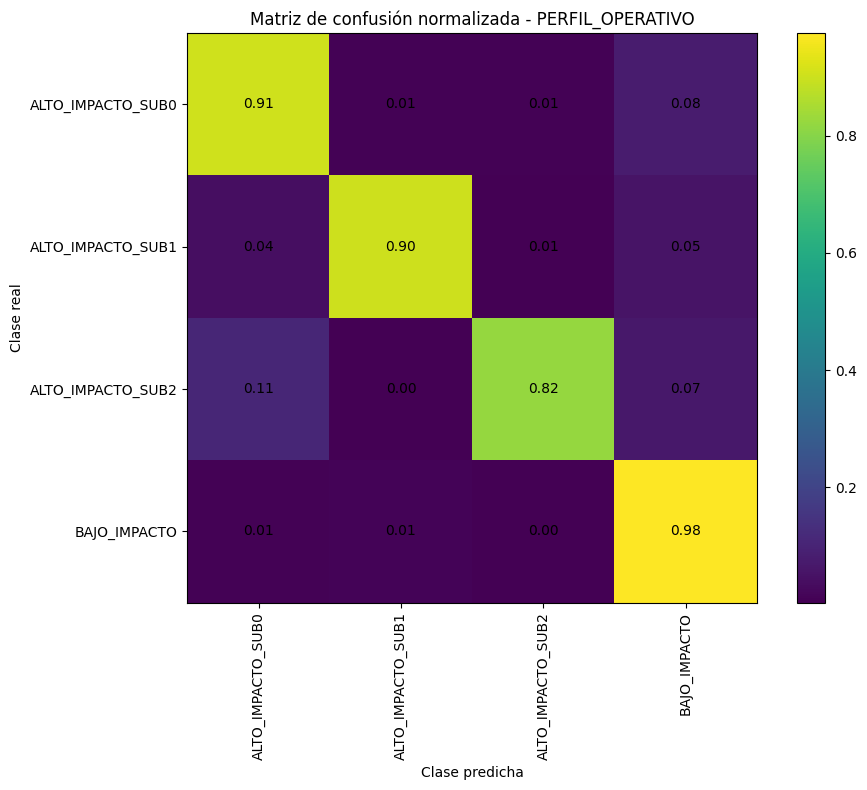

Top 30 variables más importantes:


,feature,importancia
36,temp_std,0.101755
22,sp_max,0.100969
25,rh_mean,0.070195
34,temp_max,0.058518
3,ANIO,0.047725
27,rh_min,0.034545
21,sp_mean,0.034188
13,prep_mean,0.032756
11,MES_sin,0.031126
23,sp_min,0.030229


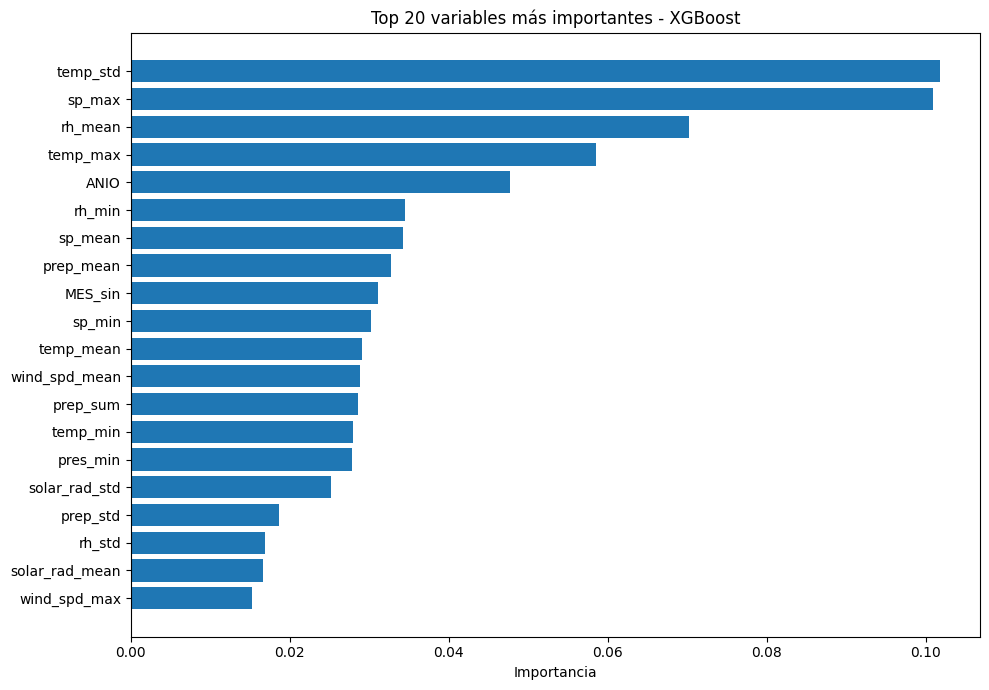

In [ ]:
# ============================================================
# 14. MATRIZ DE CONFUSIÓN E IMPORTANCIA DE VARIABLES
# ============================================================

# ------------------------------------------------------------
# Matriz de confusión
# ------------------------------------------------------------
matriz_confusion = confusion_matrix(
    y_test_enc,
    y_test_pred,
    labels=np.arange(len(clases_perfil))
)

matriz_confusion_df = pd.DataFrame(
    matriz_confusion,
    index=[f"Real_{c}" for c in clases_perfil],
    columns=[f"Pred_{c}" for c in clases_perfil]
)

print("Matriz de confusión absoluta:")
display(matriz_confusion_df)

matriz_confusion_norm = normalizar_matriz_confusion(matriz_confusion)

matriz_confusion_norm_df = pd.DataFrame(
    matriz_confusion_norm,
    index=[f"Real_{c}" for c in clases_perfil],
    columns=[f"Pred_{c}" for c in clases_perfil]
)

print("Matriz de confusión normalizada:")
display(matriz_confusion_norm_df)

plt.figure(figsize=(10, 8))
plt.imshow(matriz_confusion_norm, interpolation="nearest")
plt.title("Matriz de confusión normalizada - PERFIL_OPERATIVO")
plt.colorbar()

tick_marks = np.arange(len(clases_perfil))
plt.xticks(tick_marks, clases_perfil, rotation=90)
plt.yticks(tick_marks, clases_perfil)

for i in range(len(clases_perfil)):
    for j in range(len(clases_perfil)):
        plt.text(j, i, f"{matriz_confusion_norm[i, j]:.2f}", ha="center", va="center")

plt.ylabel("Clase real")
plt.xlabel("Clase predicha")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Importancia de variables
# ------------------------------------------------------------
preprocessor_entrenado = mejor_modelo.named_steps["preprocessor"]
modelo_entrenado = mejor_modelo.named_steps["model"]

feature_names = obtener_nombres_features(
    preprocessor_entrenado,
    num_cols_sup,
    cat_cols_sup
)

importancias = modelo_entrenado.feature_importances_

importancia_df = pd.DataFrame({
    "feature": feature_names,
    "importancia": importancias
}).sort_values("importancia", ascending=False)

print("Top 30 variables más importantes:")
display(importancia_df.head(30))

plt.figure(figsize=(10, 7))
top_n = importancia_df.head(20).iloc[::-1]
plt.barh(top_n["feature"], top_n["importancia"])
plt.xlabel("Importancia")
plt.title("Top 20 variables más importantes - XGBoost")
plt.tight_layout()
plt.show()


## 15. Guardado de resultados

Esta celda guarda los objetos necesarios para reutilizar el proyecto:

- clustering inicial;
- subclustering;
- modelo XGBoost;
- label encoder;
- métricas;
- matriz de confusión;
- importancia de variables;
- predicciones sobre test;
- configuración usada.


In [ ]:
# ============================================================
# 15. GUARDADO DE RESULTADOS
# ============================================================

ruta_salida = Path(CARPETA_SALIDA)
ruta_salida.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Guardar modelos y transformadores
# ------------------------------------------------------------
joblib.dump(pipeline_cluster, ruta_salida / "pipeline_clustering_inicial.pkl")
joblib.dump(pipeline_subcluster, ruta_salida / "pipeline_subclustering_alto_impacto.pkl")
joblib.dump(mejor_modelo, ruta_salida / "pipeline_xgboost_perfil_operativo.pkl")
joblib.dump(label_encoder, ruta_salida / "label_encoder_perfil_operativo.pkl")

# ------------------------------------------------------------
# Guardar datos procesados principales
# ------------------------------------------------------------
# Se guarda en .pkl para conservar tipos de datos y no generar un CSV demasiado pesado.
df_train_perfil.to_pickle(ruta_salida / "df_train_perfil.pkl")
df_val_perfil.to_pickle(ruta_salida / "df_val_perfil.pkl")
df_test_perfil.to_pickle(ruta_salida / "df_test_perfil.pkl")
df_perfil_completo.to_pickle(ruta_salida / "df_perfil_completo.pkl")

# ------------------------------------------------------------
# Guardar métricas y tablas interpretativas
# ------------------------------------------------------------
pd.DataFrame(reporte_limpieza["resumen_clima"]).to_csv(ruta_salida / "resumen_clima.csv", index=False)
resultados_k_inicial.to_csv(ruta_salida / "metricas_k_clustering_inicial.csv", index=False)
tabla_clusters.to_csv(ruta_salida / "resumen_clusters_iniciales_train.csv", index=False)
resultados_k_sub.to_csv(ruta_salida / "metricas_k_subclustering.csv", index=False)
metricas_validacion_df.to_csv(ruta_salida / "metricas_validacion_xgboost.csv", index=False)
metricas_test_df.to_csv(ruta_salida / "metricas_test_xgboost.csv", index=False)
matriz_confusion_df.to_csv(ruta_salida / "matriz_confusion_test.csv")
matriz_confusion_norm_df.to_csv(ruta_salida / "matriz_confusion_test_normalizada.csv")
importancia_df.to_csv(ruta_salida / "importancia_variables_xgboost.csv", index=False)

# ------------------------------------------------------------
# Guardar reporte de clasificación en test
# ------------------------------------------------------------
report_dict = classification_report(
    y_test_enc,
    y_test_pred,
    labels=np.arange(len(clases_perfil)),
    target_names=clases_perfil,
    zero_division=0,
    output_dict=True
)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(ruta_salida / "classification_report_test.csv")

# ------------------------------------------------------------
# Guardar predicciones del test
# ------------------------------------------------------------
df_test_predicciones = df_test_perfil.copy()
df_test_predicciones["PRED_PERFIL_OPERATIVO"] = label_encoder.inverse_transform(y_test_pred)

if y_test_proba is not None:
    for idx, clase in enumerate(clases_perfil):
        df_test_predicciones[f"PROBA_{clase}"] = y_test_proba[:, idx]

df_test_predicciones.to_pickle(ruta_salida / "df_test_predicciones.pkl")
df_test_predicciones.to_csv(ruta_salida / "df_test_predicciones.csv", index=False)

# ------------------------------------------------------------
# Guardar configuración completa del experimento
# ------------------------------------------------------------
config = {
    "descripcion": "Pipeline reducido para sustentación: clustering inicial + subclustering alto impacto + XGBoost",
    "ruta_archivo": RUTA_ARCHIVO,
    "carpeta_salida": CARPETA_SALIDA,
    "random_state": RANDOM_STATE,
    "umbral_nulos": UMBRAL_NULOS,
    "porc_train": PORC_TRAIN,
    "porc_valid": PORC_VALID,
    "porc_test": PORC_TEST,
    "accuracy_objetivo": ACCURACY_OBJETIVO,
    "fecha_corte_train": str(fecha_corte_train),
    "fecha_corte_val": str(fecha_corte_val),
    "incluir_impacto_cluster_inicial": INCLUIR_IMPACTO_CLUSTER_INICIAL,
    "k_inicial_optimo": int(K_INICIAL_OPTIMO),
    "cluster_alto_impacto": int(CLUSTER_ALTO_IMPACTO),
    "variable_impacto_principal": VARIABLE_IMPACTO_PRINCIPAL,
    "k_sub_optimo": int(K_SUB_OPTIMO),
    "modelo_supervisado": MEJOR_MODELO_NOMBRE,
    "xgb_params": xgb_params_final,
    "usar_pesos_clase": USAR_PESOS_CLASE,
    "clases_perfil": clases_perfil.tolist(),
    "metricas_validacion": metricas_validacion,
    "metricas_test": metricas_test,
    "columnas_excluidas_cluster": [c for c in columnas_excluir_cluster if c in df_train_base.columns],
    "columnas_excluidas_subcluster": [c for c in columnas_excluir_subcluster if c in df_train_alto.columns],
    "columnas_excluidas_supervisado": [c for c in columnas_excluir_supervisado if c in df_train_perfil.columns],
    "columnas_numericas_supervisado": num_cols_sup,
    "columnas_categoricas_supervisado": cat_cols_sup,
    "columnas_eliminadas_por_nulos": reporte_limpieza["columnas_eliminadas_por_nulos"],
    "columnas_clima_horarias_eliminadas": reporte_limpieza["columnas_clima_horarias_eliminadas"]
}

guardar_json(config, ruta_salida / "configuracion_pipeline_sustentacion.json")

print("Resultados guardados en:")
print(CARPETA_SALIDA)

print("\nArchivos generados:")
for archivo in sorted(ruta_salida.glob("*")):
    print("-", archivo.name)


Resultados guardados en:
/content/drive/MyDrive/TEORIA_APRENDIZAJE_MAQUINAS/TAM_PIPELINE_SUSTENTACION_COMENTADO

Archivos generados:
- classification_report_test.csv
- configuracion_pipeline_sustentacion.json
- df_perfil_completo.pkl
- df_test_perfil.pkl
- df_test_predicciones.csv
- df_test_predicciones.pkl
- df_train_perfil.pkl
- df_val_perfil.pkl
- importancia_variables_xgboost.csv
- label_encoder_perfil_operativo.pkl
- matriz_confusion_test.csv
- matriz_confusion_test_normalizada.csv
- metricas_k_clustering_inicial.csv
- metricas_k_subclustering.csv
- metricas_test_xgboost.csv
- metricas_validacion_xgboost.csv
- pipeline_clustering_inicial.pkl
- pipeline_subclustering_alto_impacto.pkl
- pipeline_xgboost_perfil_operativo.pkl
- resumen_clima.csv
- resumen_clusters_iniciales_train.csv


## 16. Conclusiones para sustentación

Esta última celda imprime un resumen defendible del flujo.

Úsala para repasar rápidamente:

- qué se limpió;
- cómo se partió la base;
- cómo se crearon los perfiles;
- qué modelo se entrenó;
- qué métricas se obtuvieron;
- por qué el proyecto es útil para una empresa.


In [ ]:
# ============================================================
# 16. CONCLUSIONES PARA SUSTENTACIÓN
# ============================================================

print("="*100)
print("CONCLUSIONES PARA SUSTENTACIÓN")
print("="*100)

print("1. Se cargó y depuró el dataset base.")
print(f"   - Filas iniciales: {reporte_limpieza['filas_iniciales']}")
print(f"   - Duplicados eliminados: {reporte_limpieza['duplicados_eliminados']}")
print(f"   - Columnas eliminadas por exceso de nulos: {len(reporte_limpieza['columnas_eliminadas_por_nulos'])}")
print(f"   - Dimensión final depurada: {reporte_limpieza['dimension_final']}")

print("\n2. Se realizó una partición temporal train/validación/test.")
display(resumen_fechas)

print("\n3. Se entrenó el clustering inicial solo con train.")
print(f"   - K inicial usado: {K_INICIAL_OPTIMO}")
print(f"   - Cluster de alto impacto: {CLUSTER_ALTO_IMPACTO}")
print(f"   - Variable usada para identificar impacto: {VARIABLE_IMPACTO_PRINCIPAL}")
print("   - UITI/DURACION se usaron para descubrir impacto histórico, no como entradas del XGBoost final.")

print("\n4. Se hizo subclustering dentro del cluster de alto impacto.")
print(f"   - K subcluster usado: {K_SUB_OPTIMO}")
print("   - Se crearon tres subclases graves: ALTO_IMPACTO_SUB0, SUB1 y SUB2.")
print("   - Los eventos fuera del cluster grave quedan como BAJO_IMPACTO.")

print("\n5. Se entrenó XGBoost como modelo supervisado final.")
print(f"   - Clases del target: {', '.join(clases_perfil)}")
print("   - Entradas: variables técnicas, temporales y climáticas.")
print("   - Excluidas: UITI, DURACION, CLUSTER, SUBCLUSTER_ALTO, PERFIL_OPERATIVO y variables objetivo/posteriores.")

print("\n6. Métricas finales en test:")
print(f"   - Accuracy: {acc_test:.4f}")
print(f"   - F1 macro: {f1_macro_test:.4f}")
print(f"   - F1 weighted: {f1_weighted_test:.4f}")
print(f"   - Precision macro: {precision_macro_test:.4f}")
print(f"   - Recall macro: {recall_macro_test:.4f}")

if not np.isnan(roc_auc_macro_test):
    print(f"   - ROC AUC macro: {roc_auc_macro_test:.4f}")
else:
    print("   - ROC AUC macro: no disponible")

if acc_test >= ACCURACY_OBJETIVO:
    print(f"\nResultado: el modelo supera el objetivo mínimo de {ACCURACY_OBJETIVO:.0%} de accuracy.")
else:
    print(f"\nResultado: el modelo no alcanza el objetivo mínimo de {ACCURACY_OBJETIVO:.0%} de accuracy.")

print("""
Interpretación de negocio:
El proyecto convierte una base histórica de fallas eléctricas en un sistema de clasificación de perfiles operativos.
Primero identifica eventos de alto impacto histórico, luego divide esos eventos críticos en tres subperfiles, y finalmente
entrena XGBoost para reconocer esos perfiles usando variables disponibles de red, tiempo y clima.

Interés empresarial:
Una empresa eléctrica podría usar este enfoque para priorizar fallas, orientar cuadrillas, detectar condiciones asociadas
a eventos críticos y construir tableros de gestión operativa.
""")


CONCLUSIONES PARA SUSTENTACIÓN
1. Se cargó y depuró el dataset base.
   - Filas iniciales: 661811
   - Duplicados eliminados: 4587
   - Columnas eliminadas por exceso de nulos: 25
   - Dimensión final depurada: (657224, 68)

2. Se realizó una partición temporal train/validación/test.


,Conjunto,Filas,Porcentaje,Fecha mínima,Fecha máxima
0,Train,452830,68.900405,2024-07-01 00:00:01,2025-04-25 04:21:10
1,Validación,101109,15.384253,2025-04-25 04:35:06,2025-07-07 05:51:00
2,Test,103285,15.715342,2025-07-07 05:57:23,2025-09-08 00:29:25



3. Se entrenó el clustering inicial solo con train.
   - K inicial usado: 2
   - Cluster de alto impacto: 0
   - Variable usada para identificar impacto: UITI
   - UITI/DURACION se usaron para descubrir impacto histórico, no como entradas del XGBoost final.

4. Se hizo subclustering dentro del cluster de alto impacto.
   - K subcluster usado: 3
   - Se crearon tres subclases graves: ALTO_IMPACTO_SUB0, SUB1 y SUB2.
   - Los eventos fuera del cluster grave quedan como BAJO_IMPACTO.

5. Se entrenó XGBoost como modelo supervisado final.
   - Clases del target: ALTO_IMPACTO_SUB0, ALTO_IMPACTO_SUB1, ALTO_IMPACTO_SUB2, BAJO_IMPACTO
   - Entradas: variables técnicas, temporales y climáticas.
   - Excluidas: UITI, DURACION, CLUSTER, SUBCLUSTER_ALTO, PERFIL_OPERATIVO y variables objetivo/posteriores.

6. Métricas finales en test:
   - Accuracy: 0.9503
   - F1 macro: 0.9029
   - F1 weighted: 0.9505
   - Precision macro: 0.9068
   - Recall macro: 0.9015
   - ROC AUC macro: 0.9961

Resultado: el m

VISUALIZACIÓN FINAL DE CLUSTERS Y PERFILES OPERATIVOS
Total de eventos disponibles para visualización: 657,224
Eventos usados en la visualización: 35,000

Variables usadas para la visualización 2D: 61
Numéricas: 53
Categóricas: 8

Varianza explicada por las 2 dimensiones visuales: 0.3202

Distribución del clustering inicial K=2:


,CLUSTER,CLUSTER_INICIAL_INTERPRETADO,cantidad,UITI_promedio,UITI_mediana,DURACION_promedio,DURACION_mediana,porcentaje
0,0,CLUSTER_ALTO_IMPACTO,342406,425.453,35.767,2.096,0.033,52.1
1,1,CLUSTER_BAJO_O_NORMAL,314818,293.790,22.901,1.993,0.031,47.9



Distribución de los perfiles operativos finales:


,PERFIL_OPERATIVO,cantidad,UITI_promedio,UITI_mediana,DURACION_promedio,DURACION_mediana,porcentaje
3,BAJO_IMPACTO,314818,293.790,22.901,1.993,0.031,47.90
0,ALTO_IMPACTO_SUB0,114697,460.891,42.575,1.921,0.033,17.45
1,ALTO_IMPACTO_SUB1,138014,448.053,50.849,2.007,0.038,21.00
2,ALTO_IMPACTO_SUB2,89695,345.363,17.319,2.457,0.024,13.65


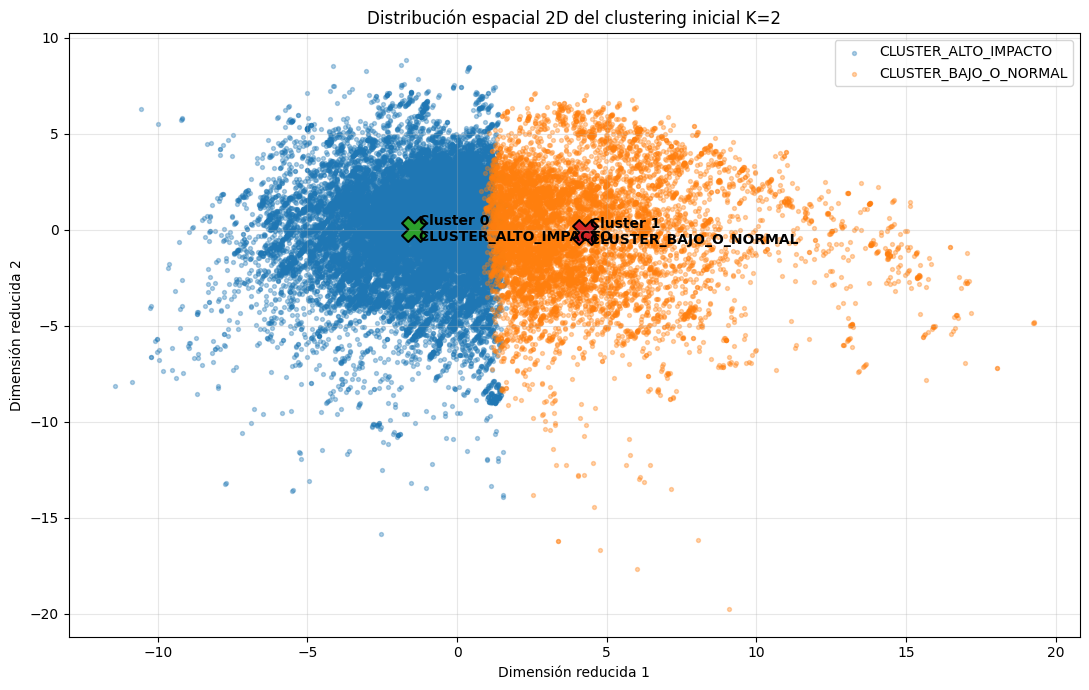


Centros visuales del clustering inicial:


,CLUSTER,CLUSTER_INICIAL_INTERPRETADO,DIM_1,DIM_2
0,0,CLUSTER_ALTO_IMPACTO,-1.4326,0.0127
1,1,CLUSTER_BAJO_O_NORMAL,4.2699,-0.1236


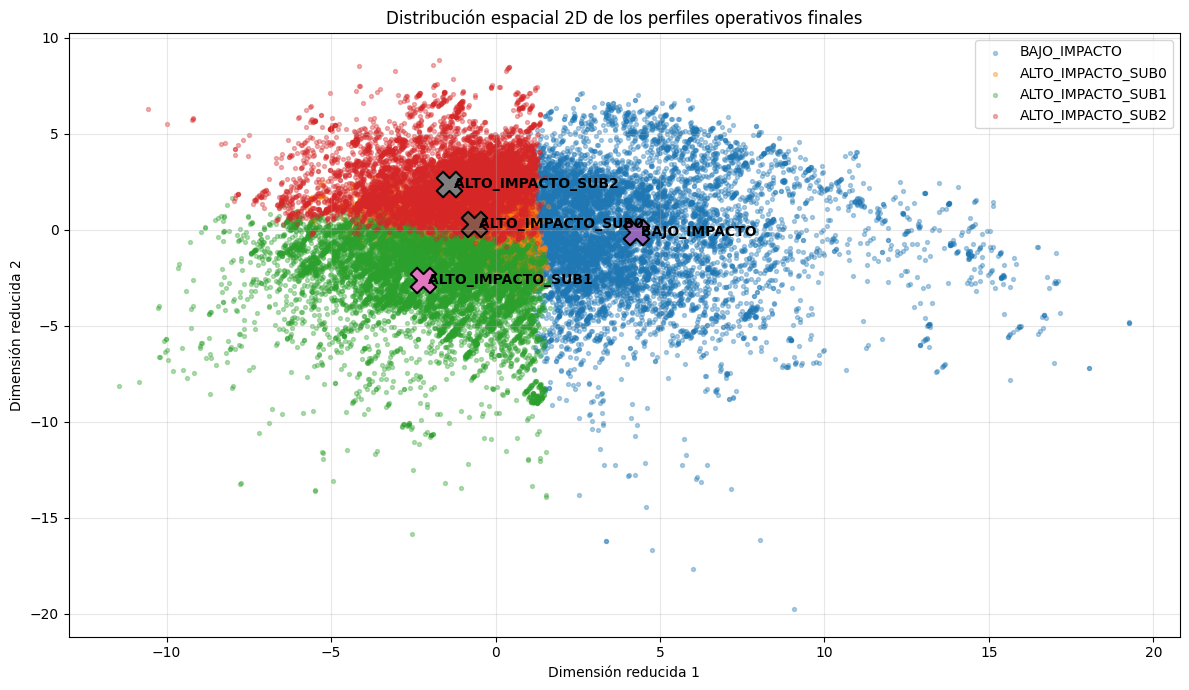


Centros visuales de los perfiles finales:


,PERFIL_OPERATIVO,DIM_1,DIM_2
3,BAJO_IMPACTO,4.2699,-0.1236
0,ALTO_IMPACTO_SUB0,-0.6600,0.2673
1,ALTO_IMPACTO_SUB1,-2.2105,-2.6204
2,ALTO_IMPACTO_SUB2,-1.4272,2.3913


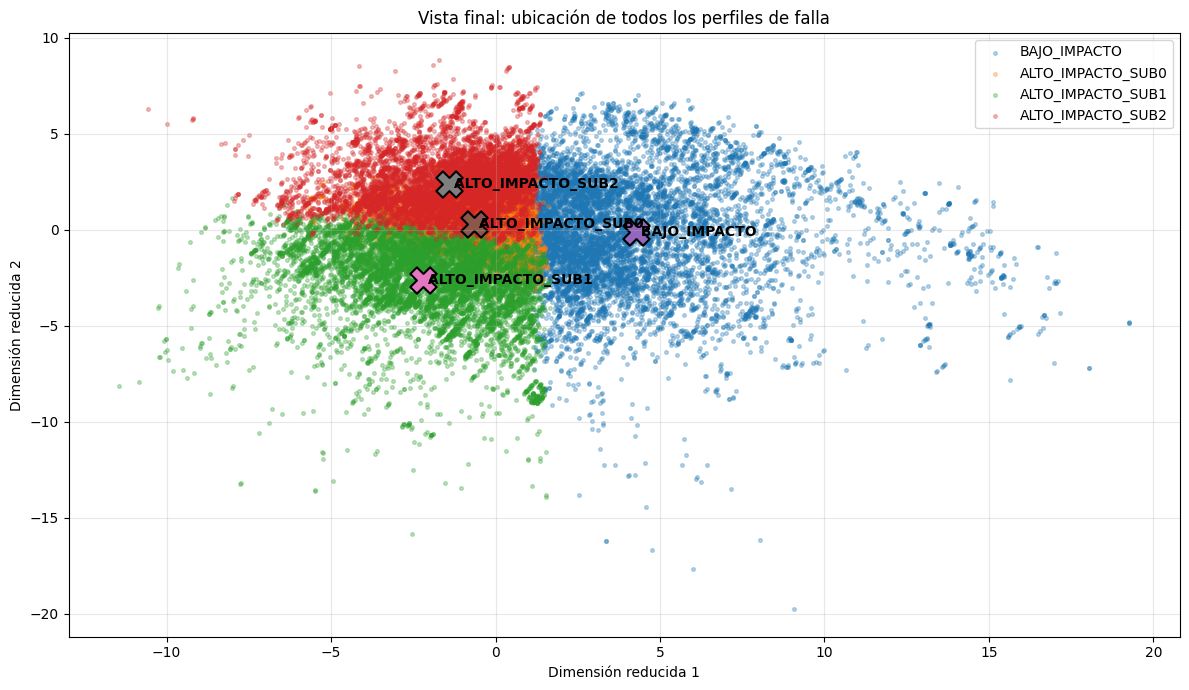


LECTURA PARA SUSTENTACIÓN:

1. La primera gráfica muestra el clustering inicial K=2.
   Ese paso separa las fallas en dos grandes grupos históricos:
   bajo o normal impacto y alto impacto.

2. La segunda gráfica muestra los perfiles finales.
   El grupo de alto impacto fue dividido en tres subclases:
   ALTO_IMPACTO_SUB0, ALTO_IMPACTO_SUB1 y ALTO_IMPACTO_SUB2.

3. Cada punto representa una falla eléctrica.
   La ubicación del punto no es geográfica, sino una representación reducida
   de sus variables técnicas, temporales y meteorológicas.

4. Las X grandes indican el centro visual de cada cluster o perfil.
   Esto permite ver dónde se ubica cada grupo dentro del espacio de variables.

5. El resultado final del proyecto no es solo detectar fallas graves,
   sino distinguir varios tipos de fallas graves para apoyar decisiones operativas.



In [ ]:
# ============================================================
# VISUALIZACIÓN FINAL: TODOS LOS CLUSTERS Y SU DISTRIBUCIÓN ESPACIAL
# ============================================================

# OBJETIVO:
# Mostrar al final del cuaderno cómo quedaron ubicados visualmente:
#   1) Los 2 clusters iniciales.
#   2) Los 4 perfiles operativos finales.
#
# IMPORTANTE:
# Esta gráfica NO es un mapa geográfico.
# Es una visualización 2D del espacio de variables.
#
# Es decir:
# Muchas variables técnicas, temporales y meteorológicas
# → se transforman numéricamente
# → se reducen a 2 dimensiones
# → se grafican los grupos.

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("="*110)
print("VISUALIZACIÓN FINAL DE CLUSTERS Y PERFILES OPERATIVOS")
print("="*110)

# ------------------------------------------------------------
# 1. Unir train, validación y test
# ------------------------------------------------------------

df_vis = pd.concat([
    df_train_perfil.assign(CONJUNTO="train"),
    df_val_perfil.assign(CONJUNTO="validacion"),
    df_test_perfil.assign(CONJUNTO="test")
], axis=0, ignore_index=True)

print(f"Total de eventos disponibles para visualización: {len(df_vis):,}")

# ------------------------------------------------------------
# 2. Crear interpretación del clustering inicial K=2
# ------------------------------------------------------------

# El cluster de alto impacto ya fue identificado previamente.
# Si existe CLUSTER_ALTO_IMPACTO, se usa para nombrar los grupos.
# Si no existe, se muestran simplemente como Cluster 0 y Cluster 1.

if "CLUSTER_ALTO_IMPACTO" in globals():
    df_vis["CLUSTER_INICIAL_INTERPRETADO"] = np.where(
        df_vis["CLUSTER"] == CLUSTER_ALTO_IMPACTO,
        "CLUSTER_ALTO_IMPACTO",
        "CLUSTER_BAJO_O_NORMAL"
    )
else:
    df_vis["CLUSTER_INICIAL_INTERPRETADO"] = "CLUSTER_" + df_vis["CLUSTER"].astype(str)

# ------------------------------------------------------------
# 3. Tomar muestra estratificada para que la gráfica sea legible
# ------------------------------------------------------------

MAX_PUNTOS_GRAFICO = 35000

# Tomamos muestra por perfil operativo para que no desaparezcan las clases pequeñas.
n_perfiles = df_vis["PERFIL_OPERATIVO"].nunique()

df_sample = (
    df_vis
    .groupby("PERFIL_OPERATIVO", group_keys=False)
    .apply(lambda x: x.sample(
        min(len(x), max(1, MAX_PUNTOS_GRAFICO // n_perfiles)),
        random_state=42
    ))
    .reset_index(drop=True)
)

print(f"Eventos usados en la visualización: {len(df_sample):,}")

# ------------------------------------------------------------
# 4. Seleccionar columnas para construir el espacio 2D
# ------------------------------------------------------------

# Se excluyen variables que son respuestas, etiquetas, fechas crudas
# o variables de impacto directo.
#
# UITI y DURACION se excluyen porque fueron usadas para construir
# la noción histórica de impacto, pero no deben dominar esta visualización
# del espacio predictivo.

columnas_excluir = [
    "CLUSTER",
    "CLUSTER_INICIAL_INTERPRETADO",
    "SUBCLUSTER_ALTO",
    "PERFIL_OPERATIVO",
    "TARGET_ALTO_IMPACTO",
    "CONJUNTO",
    "FECHA",
    "FECHA_OPERACION",
    "UITI",
    "DURACION",
    "COD_CAUSA",
    "TIPO_TAXONOMIA",
    "CLASE"
]

columnas_features_vis = [
    c for c in df_sample.columns
    if c not in columnas_excluir
]

X_vis = df_sample[columnas_features_vis].copy()

# ------------------------------------------------------------
# 5. Separar variables numéricas y categóricas
# ------------------------------------------------------------

columnas_numericas = X_vis.select_dtypes(include=["number", "bool"]).columns.tolist()

columnas_categoricas = [
    c for c in X_vis.columns
    if c not in columnas_numericas
]

# Convertir categóricas a texto evita errores por columnas con mezcla
# de números y texto, por ejemplo calibres tipo 2, 4, "1/0", "4/0".
for col in columnas_categoricas:
    X_vis[col] = X_vis[col].astype("string").fillna("__MISSING__").astype(str)

# Forzar numéricas a número.
for col in columnas_numericas:
    X_vis[col] = pd.to_numeric(X_vis[col], errors="coerce")

print(f"\nVariables usadas para la visualización 2D: {len(columnas_features_vis)}")
print(f"Numéricas: {len(columnas_numericas)}")
print(f"Categóricas: {len(columnas_categoricas)}")

# ------------------------------------------------------------
# 6. Preprocesamiento
# ------------------------------------------------------------

# Numéricas:
#   - Se imputan nulos con la mediana.
#   - Se escalan para que estén en magnitudes comparables.
#
# Categóricas:
#   - Se imputan nulos con "__MISSING__".
#   - Se convierten a variables binarias con OneHotEncoder.

try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=True)

preprocesador_vis = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), columnas_numericas),

        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="__MISSING__")),
            ("onehot", encoder)
        ]), columnas_categoricas)
    ],
    remainder="drop"
)

X_vis_pre = preprocesador_vis.fit_transform(X_vis)

# ------------------------------------------------------------
# 7. Reducción dimensional a 2D
# ------------------------------------------------------------

# TruncatedSVD permite reducir matrices grandes y dispersas,
# especialmente después del OneHotEncoder.
#
# El resultado son dos dimensiones visuales:
#   DIM_1 y DIM_2

svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_vis_pre)

df_plot = pd.DataFrame({
    "DIM_1": X_2d[:, 0],
    "DIM_2": X_2d[:, 1],
    "CLUSTER": df_sample["CLUSTER"].values,
    "CLUSTER_INICIAL_INTERPRETADO": df_sample["CLUSTER_INICIAL_INTERPRETADO"].values,
    "SUBCLUSTER_ALTO": df_sample["SUBCLUSTER_ALTO"].values if "SUBCLUSTER_ALTO" in df_sample.columns else np.nan,
    "PERFIL_OPERATIVO": df_sample["PERFIL_OPERATIVO"].values,
    "CONJUNTO": df_sample["CONJUNTO"].values
})

varianza_2d = svd.explained_variance_ratio_.sum()

print(f"\nVarianza explicada por las 2 dimensiones visuales: {varianza_2d:.4f}")

# ------------------------------------------------------------
# 8. Tabla de distribución del clustering inicial K=2
# ------------------------------------------------------------

tabla_cluster_inicial = (
    df_vis
    .groupby(["CLUSTER", "CLUSTER_INICIAL_INTERPRETADO"])
    .agg(
        cantidad=("CLUSTER", "size"),
        UITI_promedio=("UITI", "mean"),
        UITI_mediana=("UITI", "median"),
        DURACION_promedio=("DURACION", "mean"),
        DURACION_mediana=("DURACION", "median")
    )
    .reset_index()
)

tabla_cluster_inicial["porcentaje"] = (
    100 * tabla_cluster_inicial["cantidad"] / tabla_cluster_inicial["cantidad"].sum()
).round(2)

tabla_cluster_inicial = tabla_cluster_inicial.round(3)

print("\nDistribución del clustering inicial K=2:")
display(tabla_cluster_inicial)

# ------------------------------------------------------------
# 9. Tabla de distribución de perfiles finales
# ------------------------------------------------------------

tabla_perfiles = (
    df_vis
    .groupby("PERFIL_OPERATIVO")
    .agg(
        cantidad=("PERFIL_OPERATIVO", "size"),
        UITI_promedio=("UITI", "mean"),
        UITI_mediana=("UITI", "median"),
        DURACION_promedio=("DURACION", "mean"),
        DURACION_mediana=("DURACION", "median")
    )
    .reset_index()
)

tabla_perfiles["porcentaje"] = (
    100 * tabla_perfiles["cantidad"] / tabla_perfiles["cantidad"].sum()
).round(2)

orden_perfiles = [
    "BAJO_IMPACTO",
    "ALTO_IMPACTO_SUB0",
    "ALTO_IMPACTO_SUB1",
    "ALTO_IMPACTO_SUB2"
]

tabla_perfiles["orden"] = tabla_perfiles["PERFIL_OPERATIVO"].apply(
    lambda x: orden_perfiles.index(x) if x in orden_perfiles else 999
)

tabla_perfiles = (
    tabla_perfiles
    .sort_values("orden")
    .drop(columns="orden")
    .round(3)
)

print("\nDistribución de los perfiles operativos finales:")
display(tabla_perfiles)

# ------------------------------------------------------------
# 10. Gráfica 1: clustering inicial K=2
# ------------------------------------------------------------

plt.figure(figsize=(11, 7))

for grupo in df_plot["CLUSTER_INICIAL_INTERPRETADO"].unique():
    datos = df_plot[df_plot["CLUSTER_INICIAL_INTERPRETADO"] == grupo]

    plt.scatter(
        datos["DIM_1"],
        datos["DIM_2"],
        s=8,
        alpha=0.35,
        label=grupo
    )

# Centros visuales de los clusters iniciales.
centros_iniciales = (
    df_plot
    .groupby(["CLUSTER", "CLUSTER_INICIAL_INTERPRETADO"])[["DIM_1", "DIM_2"]]
    .mean()
    .reset_index()
)

for _, fila in centros_iniciales.iterrows():
    x = fila["DIM_1"]
    y = fila["DIM_2"]
    cluster_num = fila["CLUSTER"]
    interpretacion = fila["CLUSTER_INICIAL_INTERPRETADO"]

    plt.scatter(
        x,
        y,
        s=320,
        marker="X",
        edgecolors="black",
        linewidths=1.5
    )

    plt.text(
        x,
        y,
        f" Cluster {cluster_num}\n {interpretacion}",
        fontsize=10,
        weight="bold",
        ha="left",
        va="center"
    )

plt.title("Distribución espacial 2D del clustering inicial K=2")
plt.xlabel("Dimensión reducida 1")
plt.ylabel("Dimensión reducida 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nCentros visuales del clustering inicial:")
display(centros_iniciales.round(4))

# ------------------------------------------------------------
# 11. Gráfica 2: perfiles finales
# ------------------------------------------------------------

perfiles_presentes = [
    p for p in orden_perfiles
    if p in df_plot["PERFIL_OPERATIVO"].unique()
]

plt.figure(figsize=(12, 7))

for perfil in perfiles_presentes:
    datos = df_plot[df_plot["PERFIL_OPERATIVO"] == perfil]

    plt.scatter(
        datos["DIM_1"],
        datos["DIM_2"],
        s=8,
        alpha=0.35,
        label=perfil
    )

# Centros visuales de los perfiles finales.
centros_perfiles = (
    df_plot
    .groupby("PERFIL_OPERATIVO")[["DIM_1", "DIM_2"]]
    .mean()
    .reset_index()
)

centros_perfiles["orden"] = centros_perfiles["PERFIL_OPERATIVO"].apply(
    lambda x: orden_perfiles.index(x) if x in orden_perfiles else 999
)

centros_perfiles = (
    centros_perfiles
    .sort_values("orden")
    .drop(columns="orden")
)

for _, fila in centros_perfiles.iterrows():
    x = fila["DIM_1"]
    y = fila["DIM_2"]
    perfil = fila["PERFIL_OPERATIVO"]

    plt.scatter(
        x,
        y,
        s=340,
        marker="X",
        edgecolors="black",
        linewidths=1.5
    )

    plt.text(
        x,
        y,
        f" {perfil}",
        fontsize=10,
        weight="bold",
        ha="left",
        va="center"
    )

plt.title("Distribución espacial 2D de los perfiles operativos finales")
plt.xlabel("Dimensión reducida 1")
plt.ylabel("Dimensión reducida 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nCentros visuales de los perfiles finales:")
display(centros_perfiles.round(4))

# ------------------------------------------------------------
# 12. Gráfica 3: todos los clusters en una sola vista
# ------------------------------------------------------------

# Esta tercera gráfica une la lectura jerárquica:
#   - BAJO_IMPACTO
#   - ALTO_IMPACTO_SUB0
#   - ALTO_IMPACTO_SUB1
#   - ALTO_IMPACTO_SUB2

plt.figure(figsize=(12, 7))

for perfil in perfiles_presentes:
    datos = df_plot[df_plot["PERFIL_OPERATIVO"] == perfil]

    plt.scatter(
        datos["DIM_1"],
        datos["DIM_2"],
        s=7,
        alpha=0.30,
        label=perfil
    )

for _, fila in centros_perfiles.iterrows():
    x = fila["DIM_1"]
    y = fila["DIM_2"]
    perfil = fila["PERFIL_OPERATIVO"]

    plt.scatter(
        x,
        y,
        s=360,
        marker="X",
        edgecolors="black",
        linewidths=1.5
    )

    plt.text(
        x,
        y,
        f" {perfil}",
        fontsize=10,
        weight="bold",
        ha="left",
        va="center"
    )

plt.title("Vista final: ubicación de todos los perfiles de falla")
plt.xlabel("Dimensión reducida 1")
plt.ylabel("Dimensión reducida 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("""
LECTURA PARA SUSTENTACIÓN:

1. La primera gráfica muestra el clustering inicial K=2.
   Ese paso separa las fallas en dos grandes grupos históricos:
   bajo o normal impacto y alto impacto.

2. La segunda gráfica muestra los perfiles finales.
   El grupo de alto impacto fue dividido en tres subclases:
   ALTO_IMPACTO_SUB0, ALTO_IMPACTO_SUB1 y ALTO_IMPACTO_SUB2.

3. Cada punto representa una falla eléctrica.
   La ubicación del punto no es geográfica, sino una representación reducida
   de sus variables técnicas, temporales y meteorológicas.

4. Las X grandes indican el centro visual de cada cluster o perfil.
   Esto permite ver dónde se ubica cada grupo dentro del espacio de variables.

5. El resultado final del proyecto no es solo detectar fallas graves,
   sino distinguir varios tipos de fallas graves para apoyar decisiones operativas.
""")

DISTRIBUCIÓN 2D REAL VS PREDICHA - CONJUNTO TEST
Eventos en test: 103,285
Aciertos: 98,156
Errores: 5,129
Accuracy visualizado: 95.03%

Eventos usados en la visualización: 4,800

Distribución real en la muestra:


,PERFIL_REAL,cantidad
0,ALTO_IMPACTO_SUB0,1200
1,ALTO_IMPACTO_SUB1,1200
2,ALTO_IMPACTO_SUB2,1200
3,BAJO_IMPACTO,1200



Distribución predicha en la muestra:


,PERFIL_PREDICHO,cantidad
0,BAJO_IMPACTO,1402
1,ALTO_IMPACTO_SUB0,1273
2,ALTO_IMPACTO_SUB1,1115
3,ALTO_IMPACTO_SUB2,1010



Variables usadas para la visualización 2D: 61
Variables numéricas: 53
Variables categóricas: 8

Varianza explicada por las 2 dimensiones: 0.3292


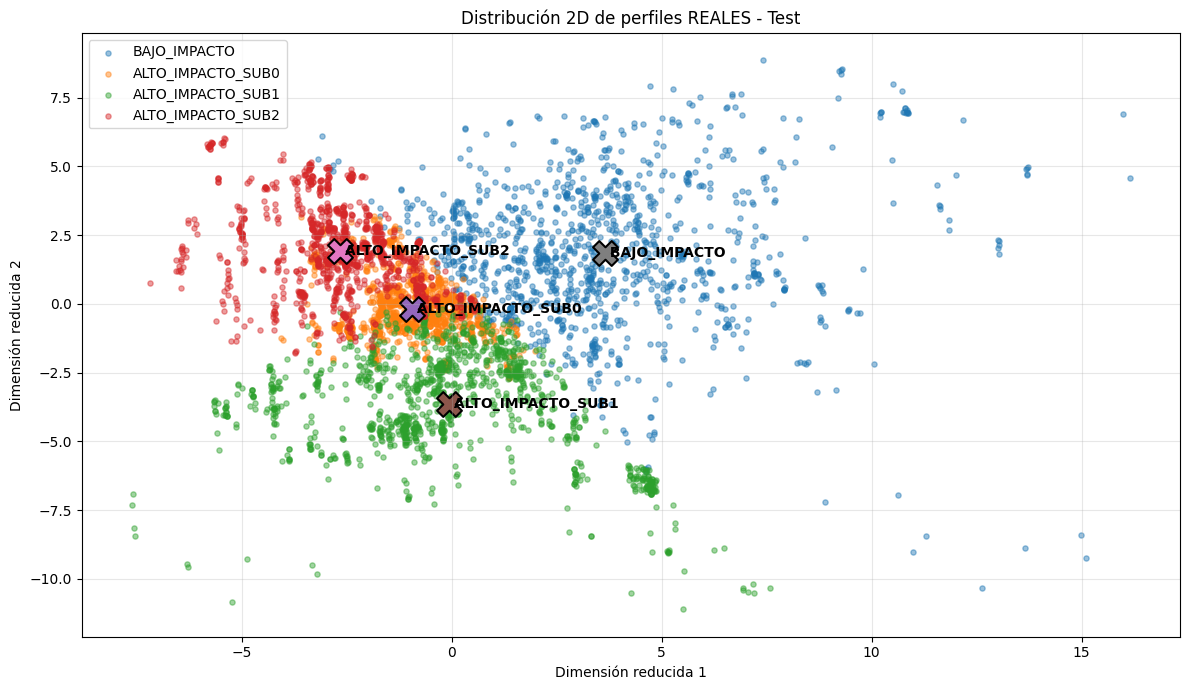

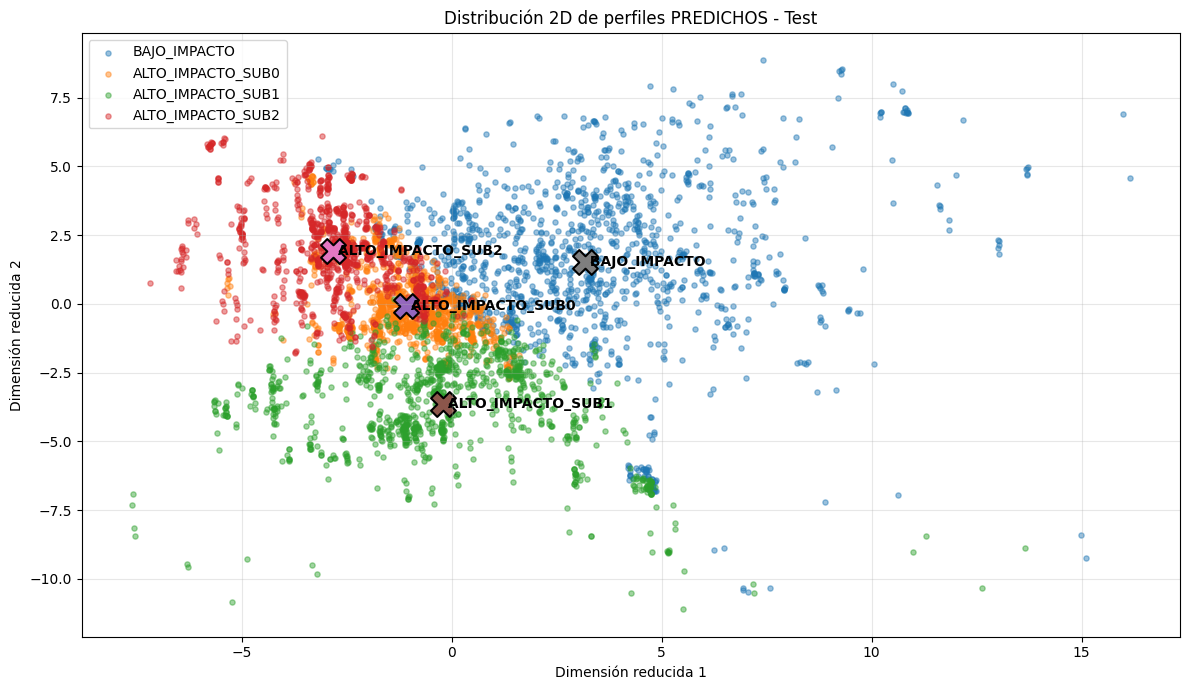

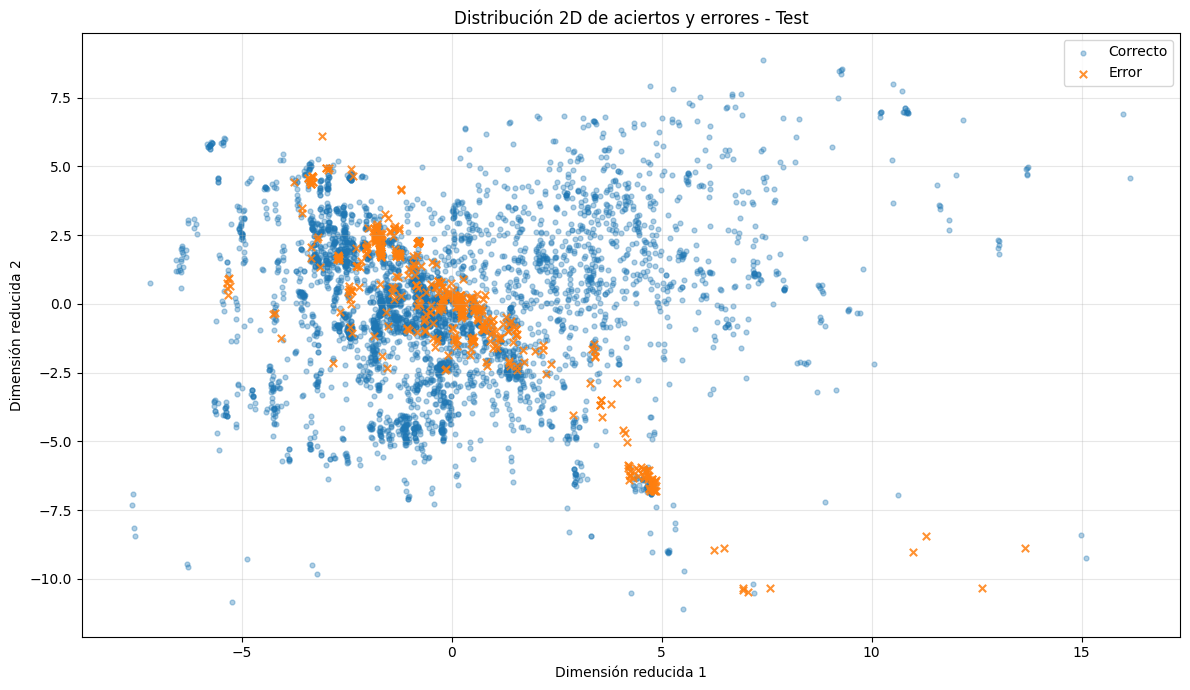


Tabla real vs predicho en la muestra visualizada:


Predicho,ALTO_IMPACTO_SUB0,ALTO_IMPACTO_SUB1,ALTO_IMPACTO_SUB2,BAJO_IMPACTO,All
Real,,,,,
ALTO_IMPACTO_SUB0,1089,9,8,94,1200
ALTO_IMPACTO_SUB1,54,1081,6,59,1200
ALTO_IMPACTO_SUB2,123,1,993,83,1200
BAJO_IMPACTO,7,24,3,1166,1200
All,1273,1115,1010,1402,4800



Tabla real vs predicho normalizada por clase real (%):


PERFIL_PREDICHO,ALTO_IMPACTO_SUB0,ALTO_IMPACTO_SUB1,ALTO_IMPACTO_SUB2,BAJO_IMPACTO
PERFIL_REAL,,,,
ALTO_IMPACTO_SUB0,90.75,0.75,0.67,7.83
ALTO_IMPACTO_SUB1,4.50,90.08,0.50,4.92
ALTO_IMPACTO_SUB2,10.25,0.08,82.75,6.92
BAJO_IMPACTO,0.58,2.00,0.25,97.17



Principales confusiones en la muestra visualizada:


,PERFIL_REAL,PERFIL_PREDICHO,cantidad,porcentaje_sobre_errores
6,ALTO_IMPACTO_SUB2,ALTO_IMPACTO_SUB0,123,26.11
2,ALTO_IMPACTO_SUB0,BAJO_IMPACTO,94,19.96
8,ALTO_IMPACTO_SUB2,BAJO_IMPACTO,83,17.62
5,ALTO_IMPACTO_SUB1,BAJO_IMPACTO,59,12.53
3,ALTO_IMPACTO_SUB1,ALTO_IMPACTO_SUB0,54,11.46
10,BAJO_IMPACTO,ALTO_IMPACTO_SUB1,24,5.10
0,ALTO_IMPACTO_SUB0,ALTO_IMPACTO_SUB1,9,1.91
1,ALTO_IMPACTO_SUB0,ALTO_IMPACTO_SUB2,8,1.70
9,BAJO_IMPACTO,ALTO_IMPACTO_SUB0,7,1.49
4,ALTO_IMPACTO_SUB1,ALTO_IMPACTO_SUB2,6,1.27



LECTURA PARA SUSTENTACIÓN:

La primera gráfica muestra dónde están ubicados los perfiles reales del conjunto test.
La segunda gráfica muestra cómo el modelo predijo esos perfiles sobre el mismo espacio 2D.
La tercera gráfica muestra dónde se concentran los aciertos y errores.

Si la distribución predicha se parece a la distribución real, significa que el modelo está reproduciendo
bien la estructura de los perfiles.

Los errores suelen aparecer en zonas de frontera o solapamiento entre perfiles.
Esto es esperable porque algunas fallas comparten características técnicas, temporales o meteorológicas.



In [ ]:
# ============================================================
# DISTRIBUCIÓN 2D: REAL VS PREDICHO
# ============================================================

# OBJETIVO:
# Comparar visualmente cómo se distribuyen los perfiles reales
# frente a los perfiles predichos por XGBoost en el conjunto de test.
#
# Esta visualización ayuda a responder:
# - ¿El modelo predice una distribución parecida a la real?
# - ¿Dónde se concentran los errores?
# - ¿Qué clases se confunden visualmente?
#
# IMPORTANTE:
# Esta NO es una gráfica geográfica.
# Es una reducción 2D del espacio de variables técnicas, temporales y meteorológicas.

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("="*100)
print("DISTRIBUCIÓN 2D REAL VS PREDICHA - CONJUNTO TEST")
print("="*100)

# ------------------------------------------------------------
# 1. Construir tabla de comparación
# ------------------------------------------------------------

df_vis = df_test_perfil.copy()

df_vis["PERFIL_REAL"] = label_encoder.inverse_transform(y_test_enc)
df_vis["PERFIL_PREDICHO"] = label_encoder.inverse_transform(y_test_pred)

df_vis["ACIERTO"] = df_vis["PERFIL_REAL"] == df_vis["PERFIL_PREDICHO"]
df_vis["RESULTADO"] = np.where(df_vis["ACIERTO"], "Correcto", "Error")

print(f"Eventos en test: {len(df_vis):,}")
print(f"Aciertos: {df_vis['ACIERTO'].sum():,}")
print(f"Errores: {(~df_vis['ACIERTO']).sum():,}")
print(f"Accuracy visualizado: {df_vis['ACIERTO'].mean():.2%}")

# ------------------------------------------------------------
# 2. Muestreo balanceado para que la gráfica sea legible
# ------------------------------------------------------------
# Puedes modificar este valor:
# 500 = muy limpio
# 1000 = recomendado
# 2000 = más completo, pero más cargado

N_POR_CLASE = 1200

df_sample = (
    df_vis
    .groupby("PERFIL_REAL", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), N_POR_CLASE),
        random_state=42
    ))
    .reset_index(drop=True)
)

print(f"\nEventos usados en la visualización: {len(df_sample):,}")

print("\nDistribución real en la muestra:")
display(
    df_sample["PERFIL_REAL"]
    .value_counts()
    .rename_axis("PERFIL_REAL")
    .reset_index(name="cantidad")
)

print("\nDistribución predicha en la muestra:")
display(
    df_sample["PERFIL_PREDICHO"]
    .value_counts()
    .rename_axis("PERFIL_PREDICHO")
    .reset_index(name="cantidad")
)

# ------------------------------------------------------------
# 3. Seleccionar variables explicativas para construir el espacio 2D
# ------------------------------------------------------------
# Excluimos:
# - etiquetas reales y predichas
# - variables creadas por el clustering
# - variables de impacto directo
# - fechas crudas
# - variables que no deberían entrar como predictores

columnas_excluir = [
    "CLUSTER",
    "SUBCLUSTER_ALTO",
    "PERFIL_OPERATIVO",
    "PERFIL_REAL",
    "PERFIL_PREDICHO",
    "ACIERTO",
    "RESULTADO",
    "TARGET_ALTO_IMPACTO",
    "FECHA",
    "FECHA_OPERACION",
    "UITI",
    "DURACION",
    "COD_CAUSA",
    "TIPO_TAXONOMIA",
    "CLASE"
]

columnas_features = [
    c for c in df_sample.columns
    if c not in columnas_excluir
]

X_vis = df_sample[columnas_features].copy()

# ------------------------------------------------------------
# 4. Separar variables numéricas y categóricas
# ------------------------------------------------------------

columnas_numericas = X_vis.select_dtypes(include=["number", "bool"]).columns.tolist()

columnas_categoricas = [
    c for c in X_vis.columns
    if c not in columnas_numericas
]

# Convertir categóricas a texto evita errores por mezcla de tipos:
# por ejemplo 2, 4, "1/0", "4/0".
for col in columnas_categoricas:
    X_vis[col] = X_vis[col].astype("string").fillna("__MISSING__").astype(str)

# Forzar numéricas.
for col in columnas_numericas:
    X_vis[col] = pd.to_numeric(X_vis[col], errors="coerce")

print(f"\nVariables usadas para la visualización 2D: {len(columnas_features)}")
print(f"Variables numéricas: {len(columnas_numericas)}")
print(f"Variables categóricas: {len(columnas_categoricas)}")

# ------------------------------------------------------------
# 5. Preprocesamiento
# ------------------------------------------------------------

try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=True)

preprocesador_vis = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), columnas_numericas),

        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="__MISSING__")),
            ("onehot", encoder)
        ]), columnas_categoricas)
    ],
    remainder="drop"
)

X_vis_pre = preprocesador_vis.fit_transform(X_vis)

# ------------------------------------------------------------
# 6. Reducción dimensional a 2D
# ------------------------------------------------------------

svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_vis_pre)

df_plot = pd.DataFrame({
    "DIM_1": X_2d[:, 0],
    "DIM_2": X_2d[:, 1],
    "PERFIL_REAL": df_sample["PERFIL_REAL"].values,
    "PERFIL_PREDICHO": df_sample["PERFIL_PREDICHO"].values,
    "ACIERTO": df_sample["ACIERTO"].values,
    "RESULTADO": df_sample["RESULTADO"].values
})

print(f"\nVarianza explicada por las 2 dimensiones: {svd.explained_variance_ratio_.sum():.4f}")

# ------------------------------------------------------------
# 7. Orden de clases
# ------------------------------------------------------------

orden_perfiles = [
    "BAJO_IMPACTO",
    "ALTO_IMPACTO_SUB0",
    "ALTO_IMPACTO_SUB1",
    "ALTO_IMPACTO_SUB2"
]

perfiles_presentes = [
    p for p in orden_perfiles
    if p in df_plot["PERFIL_REAL"].unique() or p in df_plot["PERFIL_PREDICHO"].unique()
]

# ------------------------------------------------------------
# 8. Gráfica 1: distribución REAL
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

for perfil in perfiles_presentes:
    datos = df_plot[df_plot["PERFIL_REAL"] == perfil]

    if len(datos) == 0:
        continue

    plt.scatter(
        datos["DIM_1"],
        datos["DIM_2"],
        s=14,
        alpha=0.45,
        label=perfil
    )

# Centros visuales reales
centros_reales = (
    df_plot
    .groupby("PERFIL_REAL")[["DIM_1", "DIM_2"]]
    .mean()
    .reset_index()
)

for _, fila in centros_reales.iterrows():
    x = fila["DIM_1"]
    y = fila["DIM_2"]
    perfil = fila["PERFIL_REAL"]

    plt.scatter(
        x,
        y,
        s=320,
        marker="X",
        edgecolors="black",
        linewidths=1.5
    )

    plt.text(
        x,
        y,
        f" {perfil}",
        fontsize=10,
        weight="bold",
        ha="left",
        va="center"
    )

plt.title("Distribución 2D de perfiles REALES - Test")
plt.xlabel("Dimensión reducida 1")
plt.ylabel("Dimensión reducida 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. Gráfica 2: distribución PREDICHA
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

for perfil in perfiles_presentes:
    datos = df_plot[df_plot["PERFIL_PREDICHO"] == perfil]

    if len(datos) == 0:
        continue

    plt.scatter(
        datos["DIM_1"],
        datos["DIM_2"],
        s=14,
        alpha=0.45,
        label=perfil
    )

# Centros visuales predichos
centros_predichos = (
    df_plot
    .groupby("PERFIL_PREDICHO")[["DIM_1", "DIM_2"]]
    .mean()
    .reset_index()
)

for _, fila in centros_predichos.iterrows():
    x = fila["DIM_1"]
    y = fila["DIM_2"]
    perfil = fila["PERFIL_PREDICHO"]

    plt.scatter(
        x,
        y,
        s=320,
        marker="X",
        edgecolors="black",
        linewidths=1.5
    )

    plt.text(
        x,
        y,
        f" {perfil}",
        fontsize=10,
        weight="bold",
        ha="left",
        va="center"
    )

plt.title("Distribución 2D de perfiles PREDICHOS - Test")
plt.xlabel("Dimensión reducida 1")
plt.ylabel("Dimensión reducida 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 10. Gráfica 3: aciertos vs errores
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

# Aciertos
datos_ok = df_plot[df_plot["ACIERTO"] == True]
plt.scatter(
    datos_ok["DIM_1"],
    datos_ok["DIM_2"],
    s=12,
    alpha=0.35,
    label="Correcto"
)

# Errores
datos_error = df_plot[df_plot["ACIERTO"] == False]
plt.scatter(
    datos_error["DIM_1"],
    datos_error["DIM_2"],
    s=28,
    alpha=0.85,
    marker="x",
    label="Error"
)

plt.title("Distribución 2D de aciertos y errores - Test")
plt.xlabel("Dimensión reducida 1")
plt.ylabel("Dimensión reducida 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 11. Tabla real vs predicha
# ------------------------------------------------------------

tabla_real_predicho = pd.crosstab(
    df_plot["PERFIL_REAL"],
    df_plot["PERFIL_PREDICHO"],
    rownames=["Real"],
    colnames=["Predicho"],
    margins=True
)

print("\nTabla real vs predicho en la muestra visualizada:")
display(tabla_real_predicho)

# ------------------------------------------------------------
# 12. Tabla normalizada por clase real
# ------------------------------------------------------------

tabla_real_predicho_norm = (
    pd.crosstab(
        df_plot["PERFIL_REAL"],
        df_plot["PERFIL_PREDICHO"],
        normalize="index"
    ) * 100
).round(2)

print("\nTabla real vs predicho normalizada por clase real (%):")
display(tabla_real_predicho_norm)

# ------------------------------------------------------------
# 13. Principales confusiones
# ------------------------------------------------------------

df_errores_vis = df_plot[df_plot["ACIERTO"] == False].copy()

if len(df_errores_vis) > 0:
    confusiones = (
        df_errores_vis
        .groupby(["PERFIL_REAL", "PERFIL_PREDICHO"])
        .size()
        .reset_index(name="cantidad")
        .sort_values("cantidad", ascending=False)
    )

    confusiones["porcentaje_sobre_errores"] = (
        100 * confusiones["cantidad"] / confusiones["cantidad"].sum()
    ).round(2)

    print("\nPrincipales confusiones en la muestra visualizada:")
    display(confusiones)
else:
    print("\nNo hubo errores en la muestra visualizada.")

print("""
LECTURA PARA SUSTENTACIÓN:

La primera gráfica muestra dónde están ubicados los perfiles reales del conjunto test.
La segunda gráfica muestra cómo el modelo predijo esos perfiles sobre el mismo espacio 2D.
La tercera gráfica muestra dónde se concentran los aciertos y errores.

Si la distribución predicha se parece a la distribución real, significa que el modelo está reproduciendo
bien la estructura de los perfiles.

Los errores suelen aparecer en zonas de frontera o solapamiento entre perfiles.
Esto es esperable porque algunas fallas comparten características técnicas, temporales o meteorológicas.
""")